## Problem Statement

### Business Context

The Thera bank recently saw a steep decline in the number of users of their credit card, credit cards are a good source of income for banks because of different kinds of fees charged by the banks like annual fees, balance transfer fees, and cash advance fees, late payment fees, foreign transaction fees, and others. Some fees are charged to every user irrespective of usage, while others are charged under specified circumstances.

Customers’ leaving credit cards services would lead bank to loss, so the bank wants to analyze the data of customers and identify the customers who will leave their credit card services and reason for same – so that bank could improve upon those areas

You as a Data scientist at Thera bank need to come up with a classification model that will help the bank improve its services so that customers do not renounce their credit cards

### Data Description

* CLIENTNUM: Client number. Unique identifier for the customer holding the account
* Attrition_Flag: Internal event (customer activity) variable - if the account is closed then "Attrited Customer" else "Existing Customer"
* Customer_Age: Age in Years
* Gender: Gender of the account holder
* Dependent_count: Number of dependents
* Education_Level: Educational Qualification of the account holder - Graduate, High School, Unknown, Uneducated, College(refers to college student), Post-Graduate, Doctorate
* Marital_Status: Marital Status of the account holder
* Income_Category: Annual Income Category of the account holder
* Card_Category: Type of Card
* Months_on_book: Period of relationship with the bank (in months)
* Total_Relationship_Count: Total no. of products held by the customer
* Months_Inactive_12_mon: No. of months inactive in the last 12 months
* Contacts_Count_12_mon: No. of Contacts in the last 12 months
* Credit_Limit: Credit Limit on the Credit Card
* Total_Revolving_Bal: Total Revolving Balance on the Credit Card
* Avg_Open_To_Buy: Open to Buy Credit Line (Average of last 12 months)
* Total_Amt_Chng_Q4_Q1: Change in Transaction Amount (Q4 over Q1)
* Total_Trans_Amt: Total Transaction Amount (Last 12 months)
* Total_Trans_Ct: Total Transaction Count (Last 12 months)
* Total_Ct_Chng_Q4_Q1: Change in Transaction Count (Q4 over Q1)
* Avg_Utilization_Ratio: Average Card Utilization Ratio

#### What Is a Revolving Balance?

- If we don't pay the balance of the revolving credit account in full every month, the unpaid portion carries over to the next month. That's called a revolving balance


##### What is the Average Open to buy?

- 'Open to Buy' means the amount left on your credit card to use. Now, this column represents the average of this value for the last 12 months.

##### What is the Average utilization Ratio?

- The Avg_Utilization_Ratio represents how much of the available credit the customer spent. This is useful for calculating credit scores.


##### Relation b/w Avg_Open_To_Buy, Credit_Limit and Avg_Utilization_Ratio:

- ( Avg_Open_To_Buy / Credit_Limit ) + Avg_Utilization_Ratio = 1

## **Please read the instructions carefully before starting the project.**
This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_______' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again*.

In [2]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [4]:
churn = pd.read_csv("../data/BankChurners.csv.xls")

## Data Overview

The initial steps to get an overview of any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

### Checking the shape of the dataset

In [5]:
# Checking the number of rows and columns in the training data
churn.shape ##  Complete the code to view dimensions of the train data

(10127, 21)

In [6]:
# let's create a copy of the data
data = churn.copy()

### Displaying the first few rows of the dataset

In [8]:
# let's view the first 5 rows of the data
data.head().T ##  Complete the code to view top 5 rows of the data

,0,1,2,3,4
CLIENTNUM,768805383,818770008,713982108,769911858,709106358
Attrition_Flag,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer
Customer_Age,45,49,51,40,40
Gender,M,F,M,F,M
Dependent_count,3,5,3,4,3
Education_Level,High School,Graduate,Graduate,High School,Uneducated
Marital_Status,Married,Single,Married,NaN,Married
Income_Category,$60K - $80K,Less than $40K,$80K - $120K,Less than $40K,$60K - $80K
Card_Category,Blue,Blue,Blue,Blue,Blue
Months_on_book,39,44,36,34,21


In [10]:
# let's view the last 5 rows of the data
data.tail().T ##  Complete the code to view last 5 rows of the data

,10122,10123,10124,10125,10126
CLIENTNUM,772366833,710638233,716506083,717406983,714337233
Attrition_Flag,Existing Customer,Attrited Customer,Attrited Customer,Attrited Customer,Attrited Customer
Customer_Age,50,41,44,30,43
Gender,M,M,F,M,F
Dependent_count,2,2,1,2,2
Education_Level,Graduate,NaN,High School,Graduate,Graduate
Marital_Status,Single,Divorced,Married,NaN,Married
Income_Category,$40K - $60K,$40K - $60K,Less than $40K,$40K - $60K,Less than $40K
Card_Category,Blue,Blue,Blue,Blue,Silver
Months_on_book,40,25,36,36,25


### Checking the data types of the columns for the dataset

In [11]:
# let's check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           8608 non-null   object 
 6   Marital_Status            9378 non-null   object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

### Checking for duplicate values

In [12]:
# let's check for duplicate values in the data
data.duplicated().sum() ##  Complete the code to check duplicate entries in the data

0

### Checking for missing values

In [13]:
# let's check for missing values in the data
data.isnull().sum()  ##  Complete the code to check missing entries in the train data

CLIENTNUM                      0
Attrition_Flag                 0
Customer_Age                   0
Gender                         0
Dependent_count                0
Education_Level             1519
Marital_Status               749
Income_Category                0
Card_Category                  0
Months_on_book                 0
Total_Relationship_Count       0
Months_Inactive_12_mon         0
Contacts_Count_12_mon          0
Credit_Limit                   0
Total_Revolving_Bal            0
Avg_Open_To_Buy                0
Total_Amt_Chng_Q4_Q1           0
Total_Trans_Amt                0
Total_Trans_Ct                 0
Total_Ct_Chng_Q4_Q1            0
Avg_Utilization_Ratio          0
dtype: int64

### Statistical summary of the dataset

In [14]:
# let's view the statistical summary of the numerical columns in the data
data.describe().T  ##  Complete the code to print the statitical summary of the train data

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.000,739177606.334,36903783.450,708082083.000,713036770.500,717926358.000,773143533.000,828343083.000
Customer_Age,10127.000,46.326,8.017,26.000,41.000,46.000,52.000,73.000
Dependent_count,10127.000,2.346,1.299,0.000,1.000,2.000,3.000,5.000
Months_on_book,10127.000,35.928,7.986,13.000,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.000,3.813,1.554,1.000,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.000,2.341,1.011,0.000,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.000,2.455,1.106,0.000,2.000,2.000,3.000,6.000
Credit_Limit,10127.000,8631.954,9088.777,1438.300,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.000,1162.814,814.987,0.000,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.000,7469.140,9090.685,3.000,1324.500,3474.000,9859.000,34516.000


In [15]:
data.describe(include=["object"]).T

,count,unique,top,freq
Attrition_Flag,10127,2,Existing Customer,8500
Gender,10127,2,F,5358
Education_Level,8608,6,Graduate,3128
Marital_Status,9378,3,Married,4687
Income_Category,10127,6,Less than $40K,3561
Card_Category,10127,4,Blue,9436


In [16]:
for i in data.describe(include=["object"]).columns:
    print("Unique values in", i, "are :")
    print(data[i].value_counts())
    print("*" * 50)

Unique values in Attrition_Flag are :
Existing Customer    8500
Attrited Customer    1627
Name: Attrition_Flag, dtype: int64
**************************************************
Unique values in Gender are :
F    5358
M    4769
Name: Gender, dtype: int64
**************************************************
Unique values in Education_Level are :
Graduate         3128
High School      2013
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: Education_Level, dtype: int64
**************************************************
Unique values in Marital_Status are :
Married     4687
Single      3943
Divorced     748
Name: Marital_Status, dtype: int64
**************************************************
Unique values in Income_Category are :
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
abc               1112
$120K +            727
Name: Income_Category, dtype: int64
**************************************************

In [17]:
# CLIENTNUM consists of uniques ID for clients and hence will not add value to the modeling
data.drop(["CLIENTNUM"], axis=1, inplace=True)

In [18]:
## Encoding Existing and Attrited customers to 0 and 1 respectively, for analysis.
data["Attrition_Flag"].replace("Existing Customer", 0, inplace=True)
data["Attrition_Flag"].replace("Attrited Customer", 1, inplace=True)

## Exploratory Data Analysis

#### The below functions need to be defined to carry out the Exploratory Data Analysis.

In [19]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [20]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [21]:
# function to plot stacked bar chart

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [22]:
### Function to plot distributions

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate analysis

`Customer_Age`

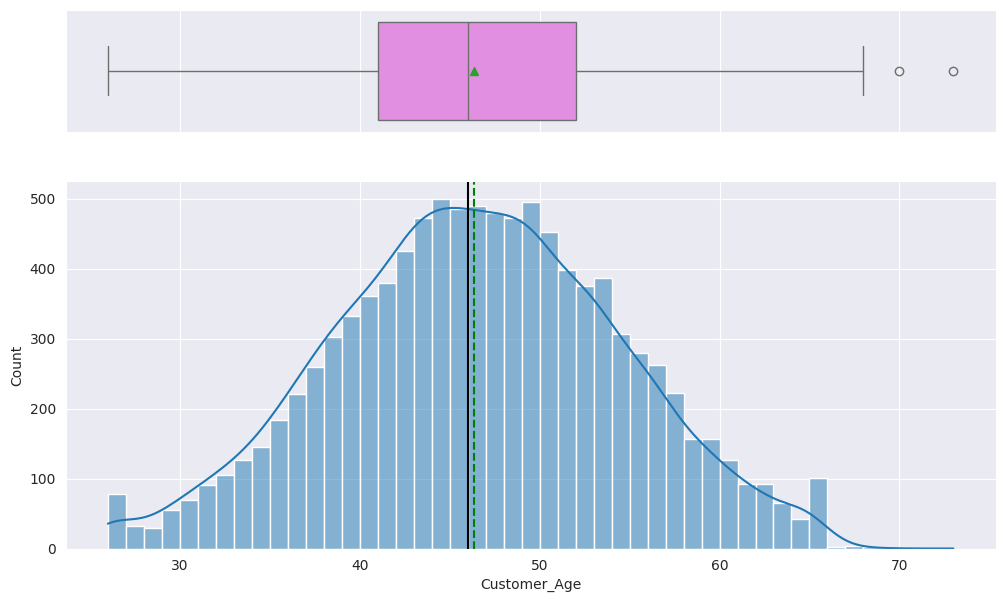

In [23]:
histogram_boxplot(data, "Customer_Age", kde=True)

`Months_on_book`

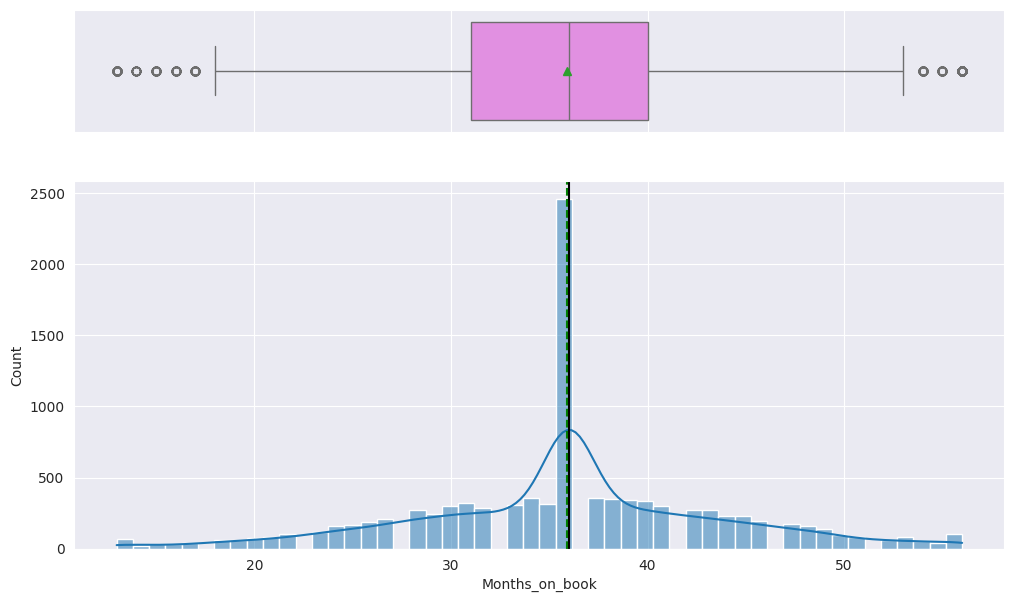

In [24]:
histogram_boxplot(data=data, feature="Months_on_book", kde=True) ## Complete the code to create histogram_boxplot for 'New_Price'

`Credit_Limit`

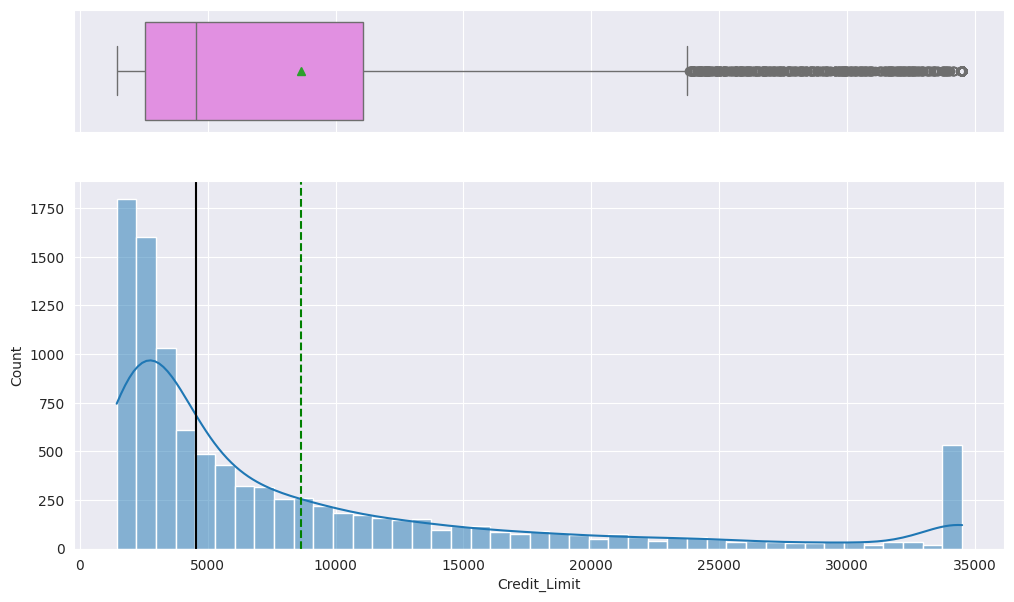

In [25]:
histogram_boxplot(data, "Credit_Limit", kde=True) ## Complete the code to create histogram_boxplot for 'New_Price'

`Total_Revolving_Bal`

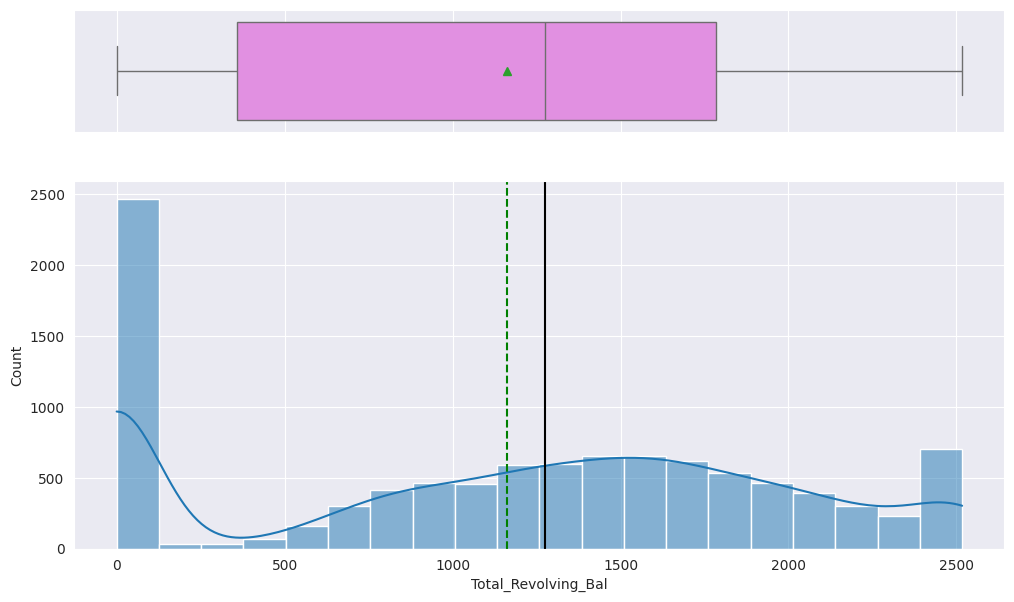

In [26]:
histogram_boxplot(data, "Total_Revolving_Bal", kde=True)  ## Complete the code to create histogram_boxplot for 'New_Price'

`Avg_Open_To_Buy`

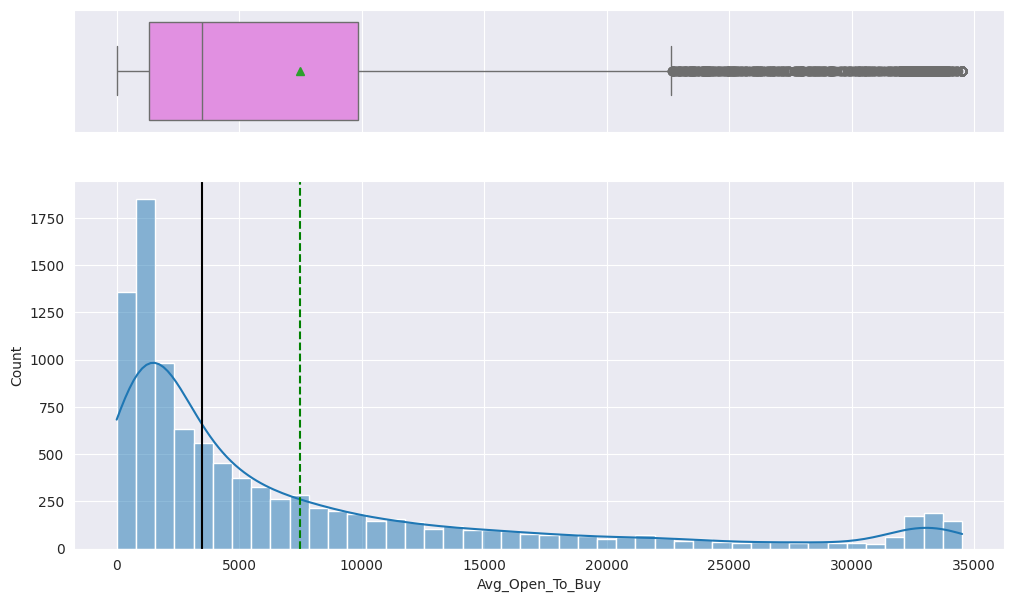

In [27]:
histogram_boxplot(data, "Avg_Open_To_Buy", kde=True)  ## Complete the code to create histogram_boxplot for 'New_Price'

`Total_Trans_Ct`

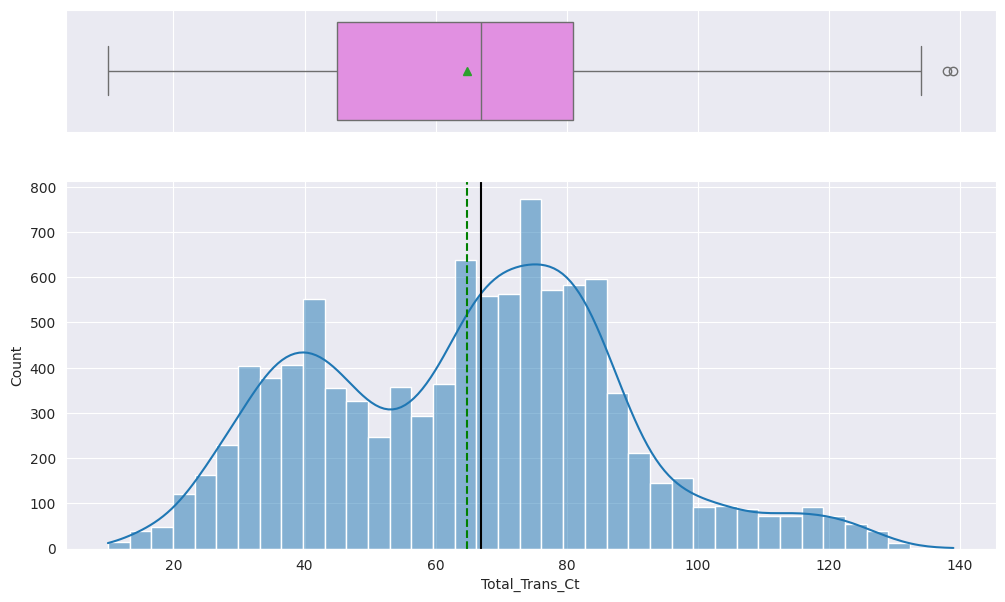

In [28]:
histogram_boxplot(data, "Total_Trans_Ct", kde=True)  ## Complete the code to create histogram_boxplot for 'New_Price'

`Total_Amt_Chng_Q4_Q1`

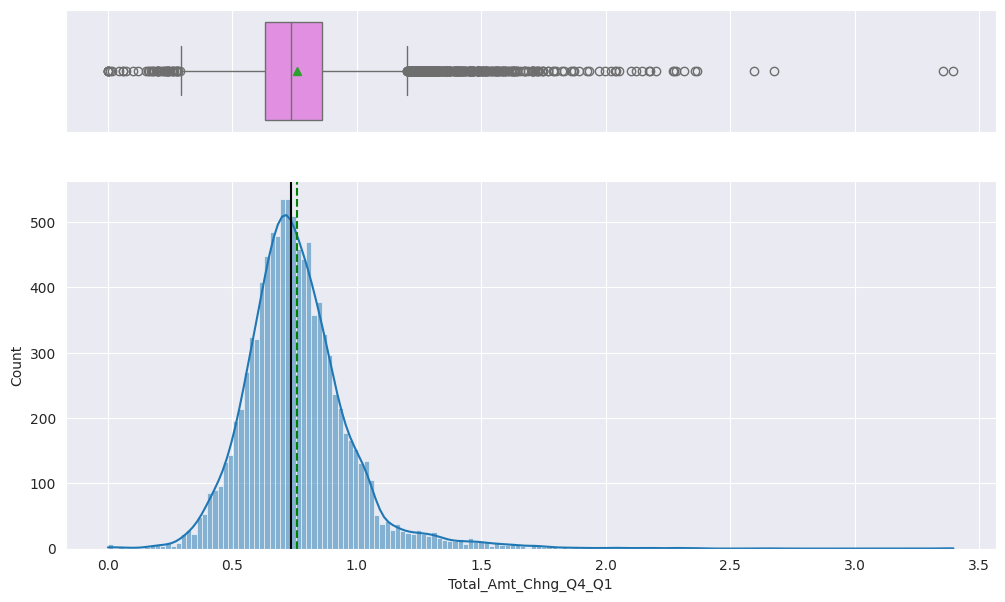

In [29]:
histogram_boxplot(data, "Total_Amt_Chng_Q4_Q1", kde=True)  ## Complete the code to create histogram_boxplot for 'New_Price'

**Let's see total transaction amount distributed**

`Total_Trans_Amt`

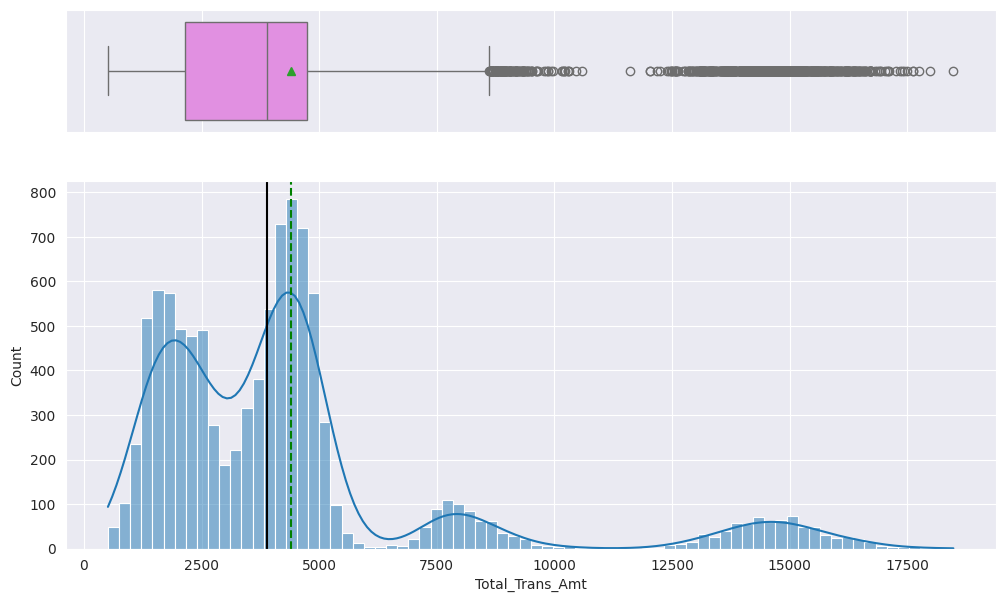

In [30]:
histogram_boxplot(data, "Total_Trans_Amt", kde=True)  ## Complete the code to create histogram_boxplot for 'New_Price'

`Total_Ct_Chng_Q4_Q1`

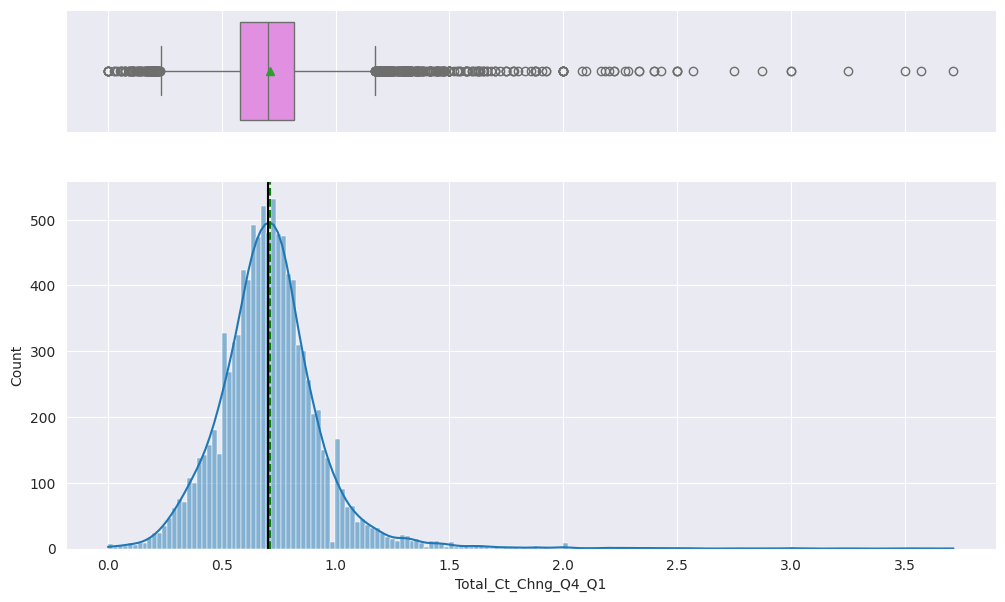

In [31]:
histogram_boxplot(data, "Total_Ct_Chng_Q4_Q1", kde=True)  ## Complete the code to create histogram_boxplot for 'New_Price'

`Avg_Utilization_Ratio`

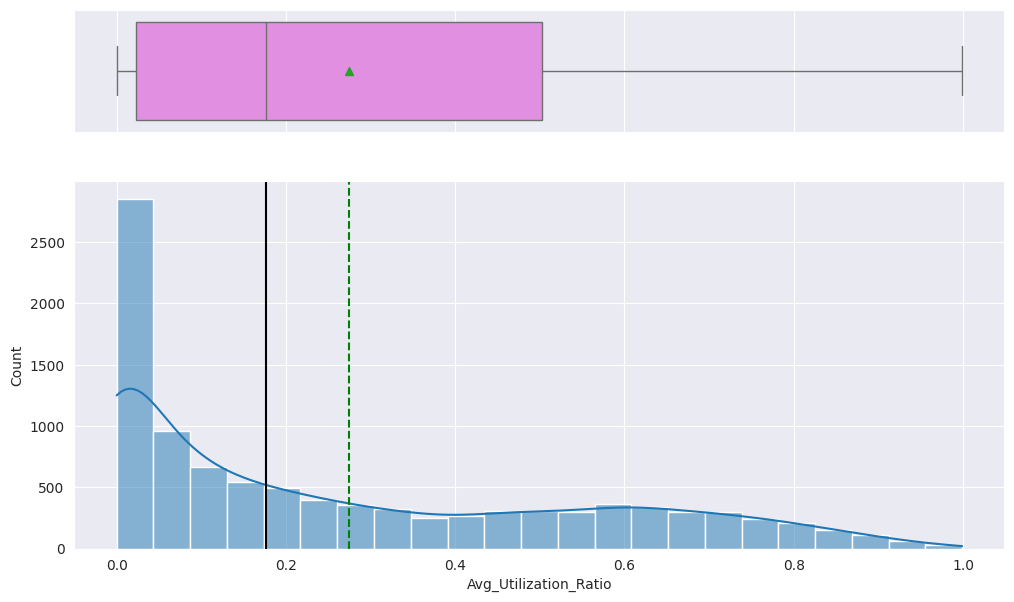

In [32]:
histogram_boxplot(data, "Avg_Utilization_Ratio", kde=True)  ## Complete the code to create histogram_boxplot for 'New_Price'

`Dependent_count`

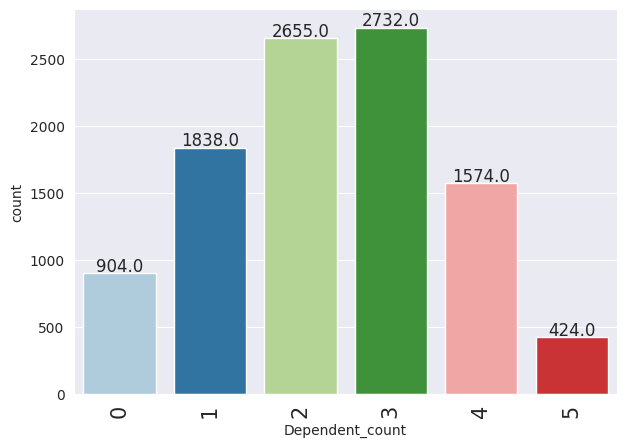

In [33]:
labeled_barplot(data, "Dependent_count")

`Total_Relationship_Count`

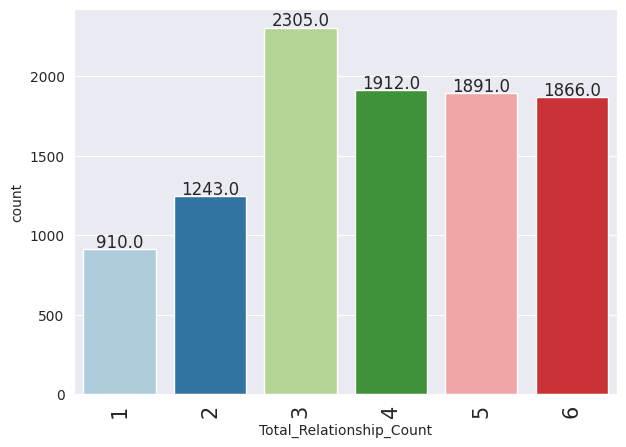

In [34]:
labeled_barplot(data, "Total_Relationship_Count") ## Complete the code to create labeled_barplot for 'Total_Relationship_Count'

`Months_Inactive_12_mon`

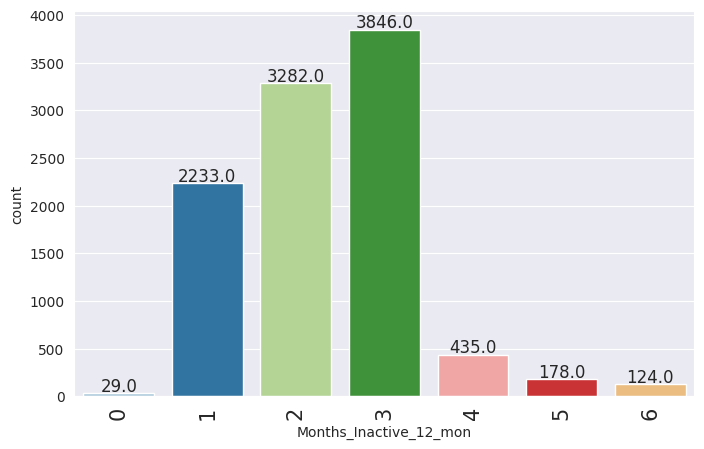

In [35]:
labeled_barplot(data, "Months_Inactive_12_mon") ## Complete the code to create labeled_barplot for 'Months_Inactive_12_mon'

`Contacts_Count_12_mon`

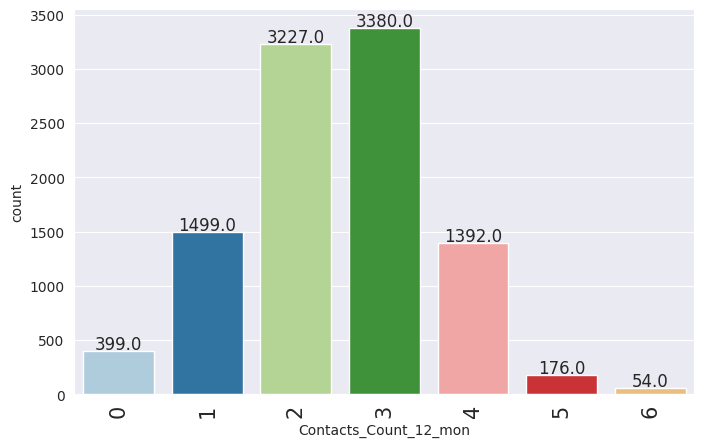

In [36]:
labeled_barplot(data, "Contacts_Count_12_mon") ## Complete the code to create labeled_barplot for 'Contacts_Count_12_mon'

`Gender`

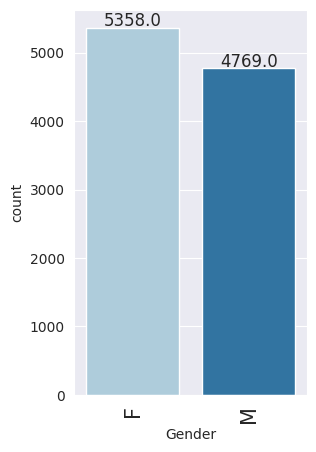

In [37]:
labeled_barplot(data, "Gender") ## Complete the code to create labeled_barplot for 'Gender'

**Let's see the distribution of the level of education of customers**

`Education_Level`

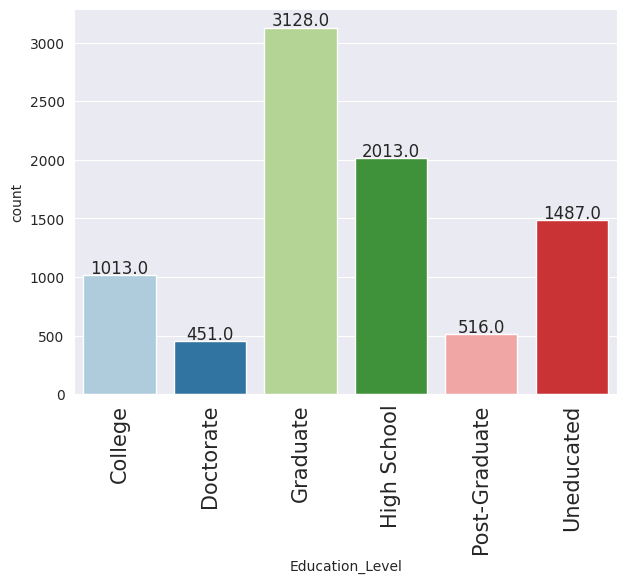

In [38]:
labeled_barplot(data, "Education_Level") ## Complete the code to create labeled_barplot for 'Education_Level'

`Marital_Status`

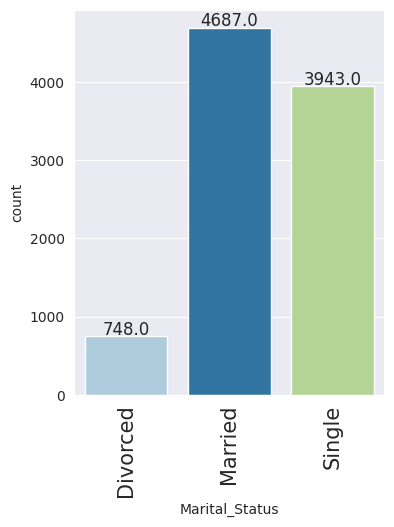

In [39]:
labeled_barplot(data, "Marital_Status") ## Complete the code to create labeled_barplot for 'Marital_Status'

**Let's see the distribution of the level of income of customers**

`Income_Category`

The occurrence of "ABC" in the Income_Category column suggests that it may be either a placeholder for missing or incomplete data or an input error. It is important to handle such values before proceeding with any analysis to maintain data quality and accuracy.

Replacing with Mode: Since "ABC" could be viewed as missing data, replacing it with the most frequent income category ensures that the dataset remains complete without introducing unnecessary bias.

In [40]:
# Replace 'ABC' with the mode (most frequent value)
mode_income = data['Income_Category'].mode()[0]
data['Income_Category'] = data['Income_Category'].replace('abc', mode_income)# Replace 'abc' with the mode (most frequent value)

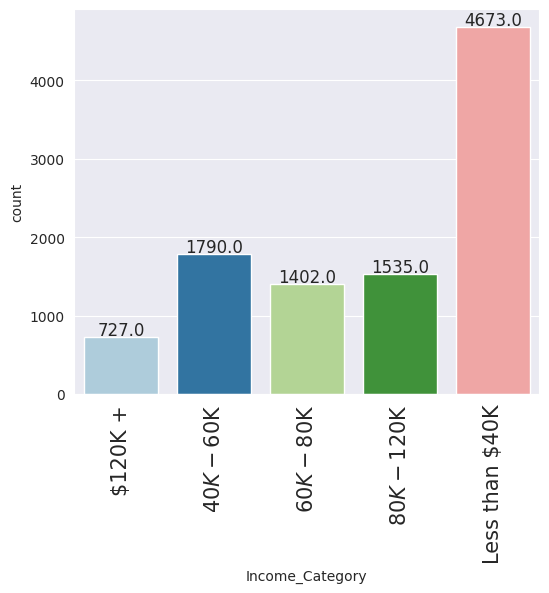

In [41]:
labeled_barplot(data, "Income_Category") ## Complete the code to create labeled_barplot for 'Income_Category'

`Card_Category`

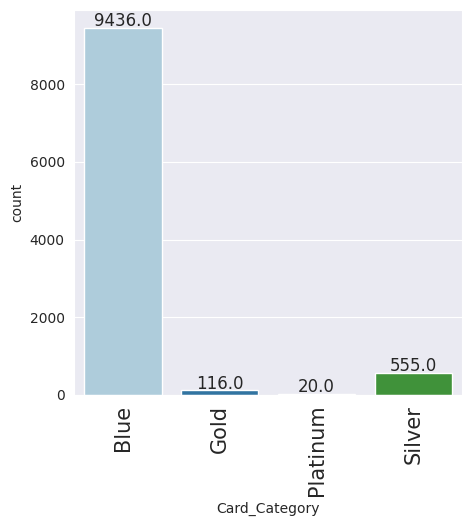

In [42]:
labeled_barplot(data, "Card_Category") ## Complete the code to create labeled_barplot for 'Card_Category'

`Attrition_Flag`

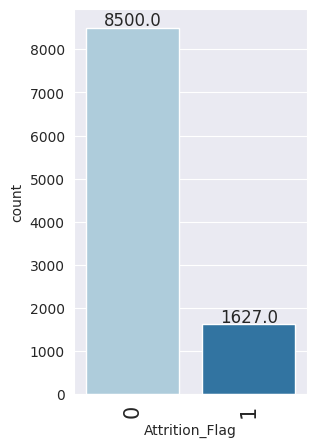

In [43]:
labeled_barplot(data, "Attrition_Flag") ## Complete the code to create labeled_barplot for 'Attrition_Flag'

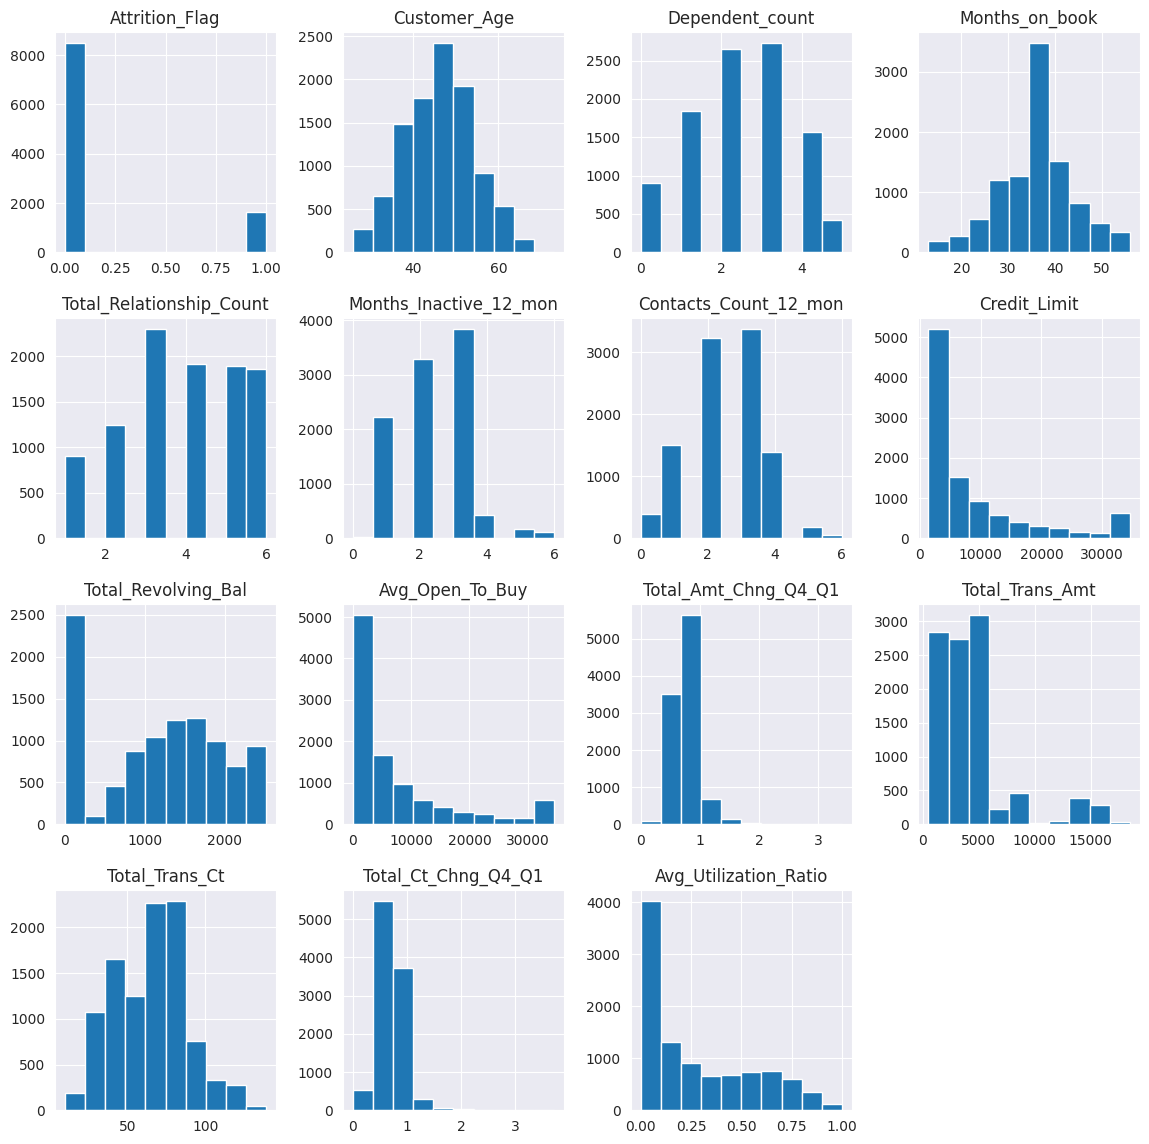

In [44]:
# creating histograms
data.hist(figsize=(14, 14))
plt.show()

### Bivariate Distributions

**Let's see the attributes that have a strong correlation with each other**

**Correlation Check**

In [45]:
data.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [46]:
# Ensure that the data has only numeric columns for the heatmap
numeric_data = data.select_dtypes(include=['float64', 'int64'])

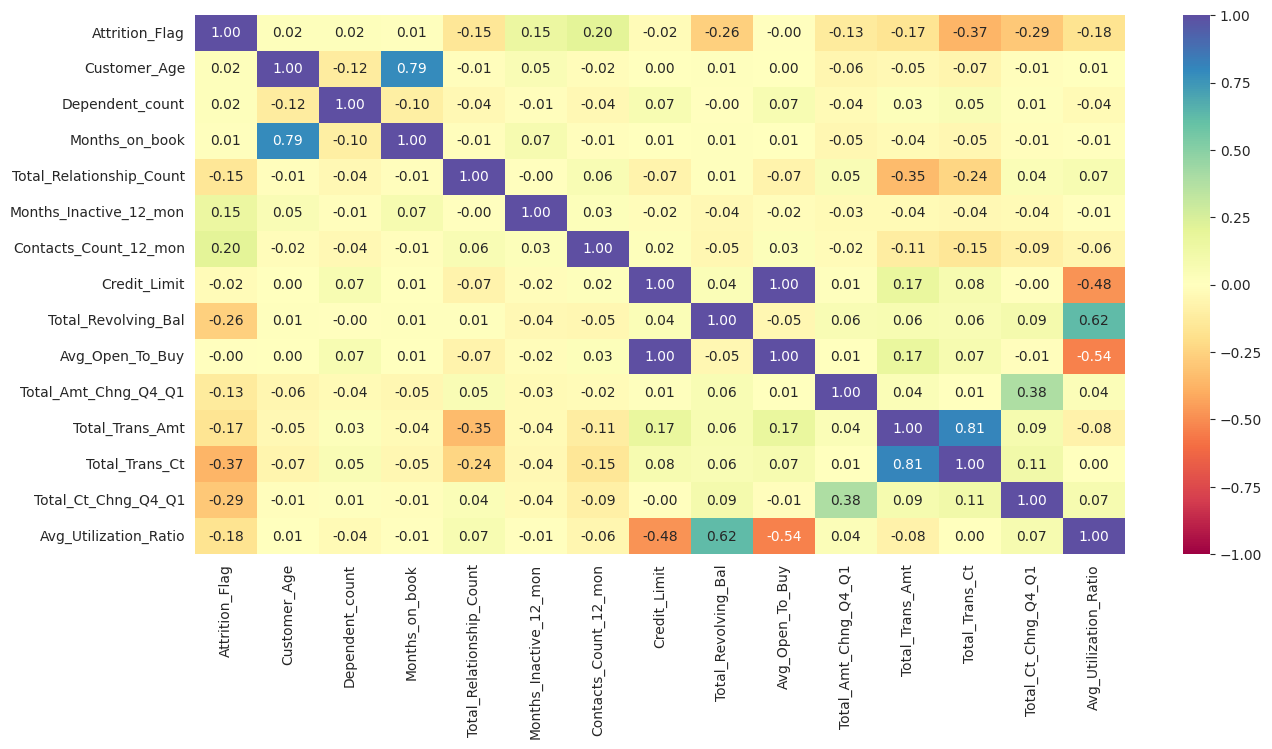

In [47]:
# Plot the heatmap for the numeric columns
plt.figure(figsize=(15, 7))
sns.heatmap(numeric_data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

`Attrition_Flag vs Gender`

Attrition_Flag     0     1    All
Gender                           
All             8500  1627  10127
F               4428   930   5358
M               4072   697   4769
------------------------------------------------------------------------------------------------------------------------


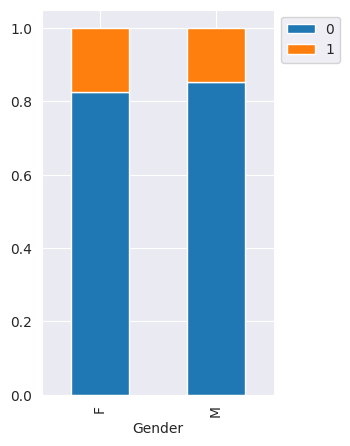

In [48]:
stacked_barplot(data, "Gender", "Attrition_Flag")

`Attrition_Flag vs Marital_Status`

Attrition_Flag     0     1   All
Marital_Status                  
All             7880  1498  9378
Married         3978   709  4687
Single          3275   668  3943
Divorced         627   121   748
------------------------------------------------------------------------------------------------------------------------


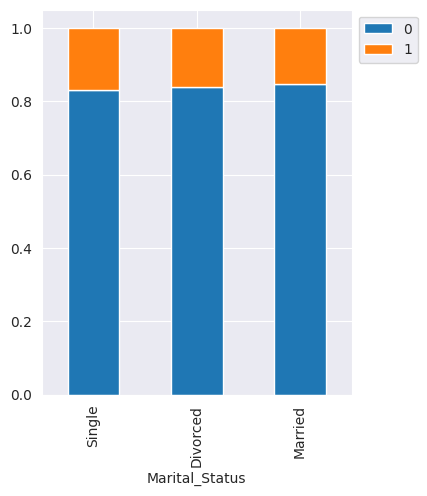

In [49]:
stacked_barplot(data, "Marital_Status", "Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Marital_Status

`Attrition_Flag vs Education_Level`

Attrition_Flag      0     1   All
Education_Level                  
All              7237  1371  8608
Graduate         2641   487  3128
High School      1707   306  2013
Uneducated       1250   237  1487
College           859   154  1013
Doctorate         356    95   451
Post-Graduate     424    92   516
------------------------------------------------------------------------------------------------------------------------


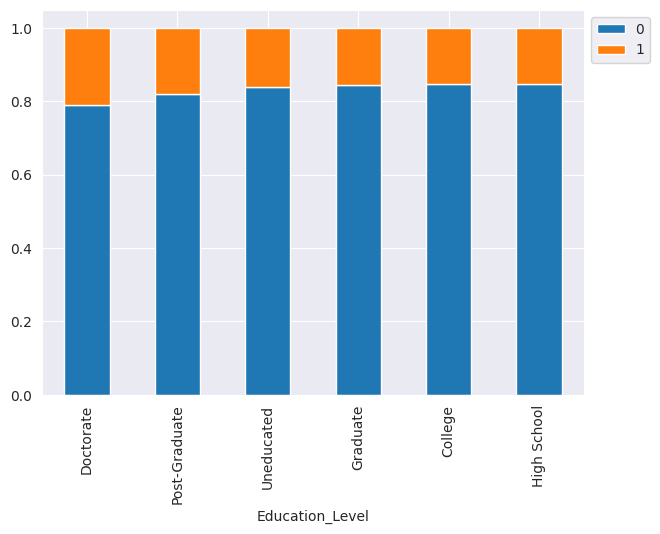

In [50]:
stacked_barplot(data, "Education_Level", "Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Education_Level

`Attrition_Flag vs Income_Category`

Attrition_Flag      0     1    All
Income_Category                   
All              8500  1627  10127
Less than $40K   3874   799   4673
$40K - $60K      1519   271   1790
$80K - $120K     1293   242   1535
$60K - $80K      1213   189   1402
$120K +           601   126    727
------------------------------------------------------------------------------------------------------------------------


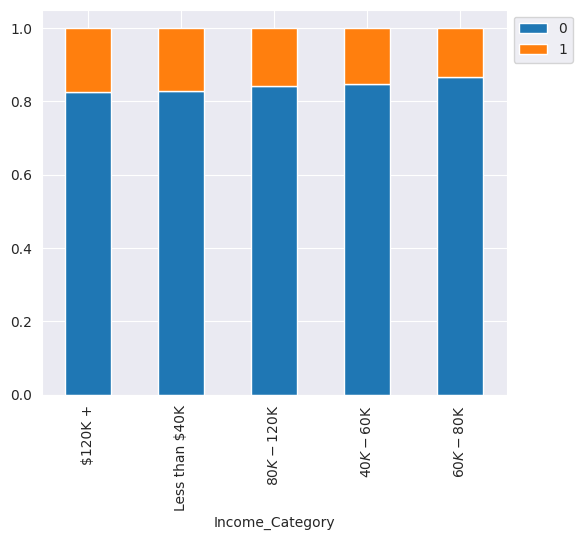

In [51]:
stacked_barplot(data, "Income_Category", "Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Income_Category

`Attrition_Flag vs Contacts_Count_12_mon`

Attrition_Flag            0     1    All
Contacts_Count_12_mon                   
All                    8500  1627  10127
3                      2699   681   3380
2                      2824   403   3227
4                      1077   315   1392
1                      1391   108   1499
5                       117    59    176
6                         0    54     54
0                       392     7    399
------------------------------------------------------------------------------------------------------------------------


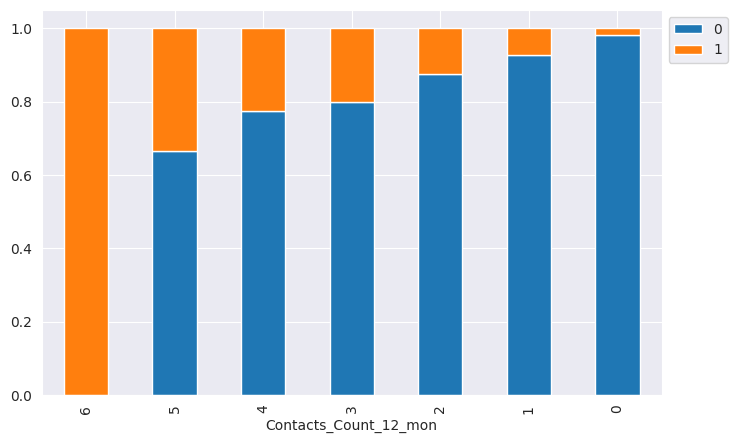

In [52]:
stacked_barplot(data, "Contacts_Count_12_mon", "Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Income_Category

**Let's see the number of months a customer was inactive in the last 12 months (Months_Inactive_12_mon) vary by the customer's account status (Attrition_Flag)**

`Attrition_Flag vs Months_Inactive_12_mon`

Attrition_Flag             0     1    All
Months_Inactive_12_mon                   
All                     8500  1627  10127
3                       3020   826   3846
2                       2777   505   3282
4                        305   130    435
1                       2133   100   2233
5                        146    32    178
6                        105    19    124
0                         14    15     29
------------------------------------------------------------------------------------------------------------------------


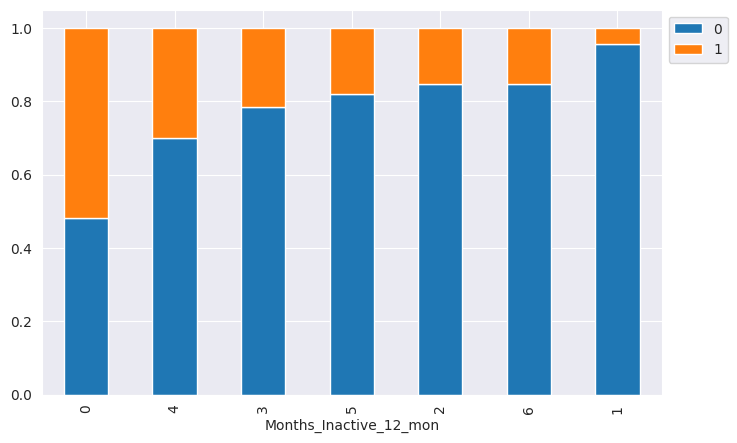

In [53]:
stacked_barplot(data, "Months_Inactive_12_mon", "Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Months_Inactive_12_mon

`Attrition_Flag vs Total_Relationship_Count`

Attrition_Flag               0     1    All
Total_Relationship_Count                   
All                       8500  1627  10127
3                         1905   400   2305
2                          897   346   1243
1                          677   233    910
5                         1664   227   1891
4                         1687   225   1912
6                         1670   196   1866
------------------------------------------------------------------------------------------------------------------------


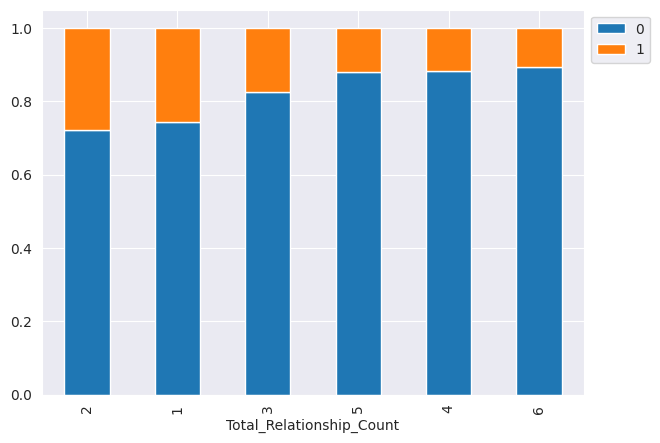

In [54]:
stacked_barplot(data, "Total_Relationship_Count", "Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Total_Relationship_Count

`Attrition_Flag vs Dependent_count`

Attrition_Flag      0     1    All
Dependent_count                   
All              8500  1627  10127
3                2250   482   2732
2                2238   417   2655
1                1569   269   1838
4                1314   260   1574
0                 769   135    904
5                 360    64    424
------------------------------------------------------------------------------------------------------------------------


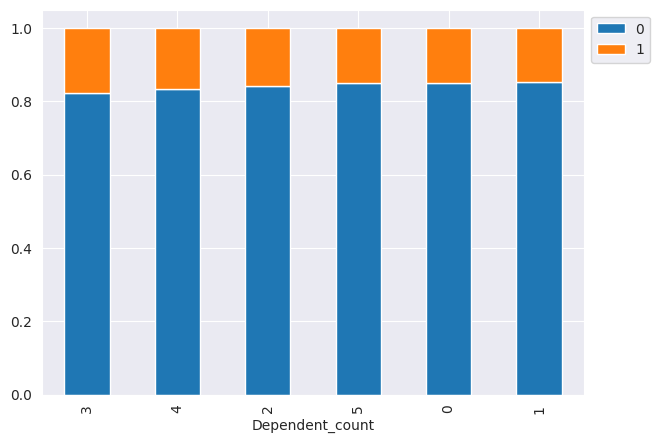

In [55]:
stacked_barplot(data, "Dependent_count", "Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Dependent_count

`Total_Revolving_Bal` vs `Attrition_Flag`

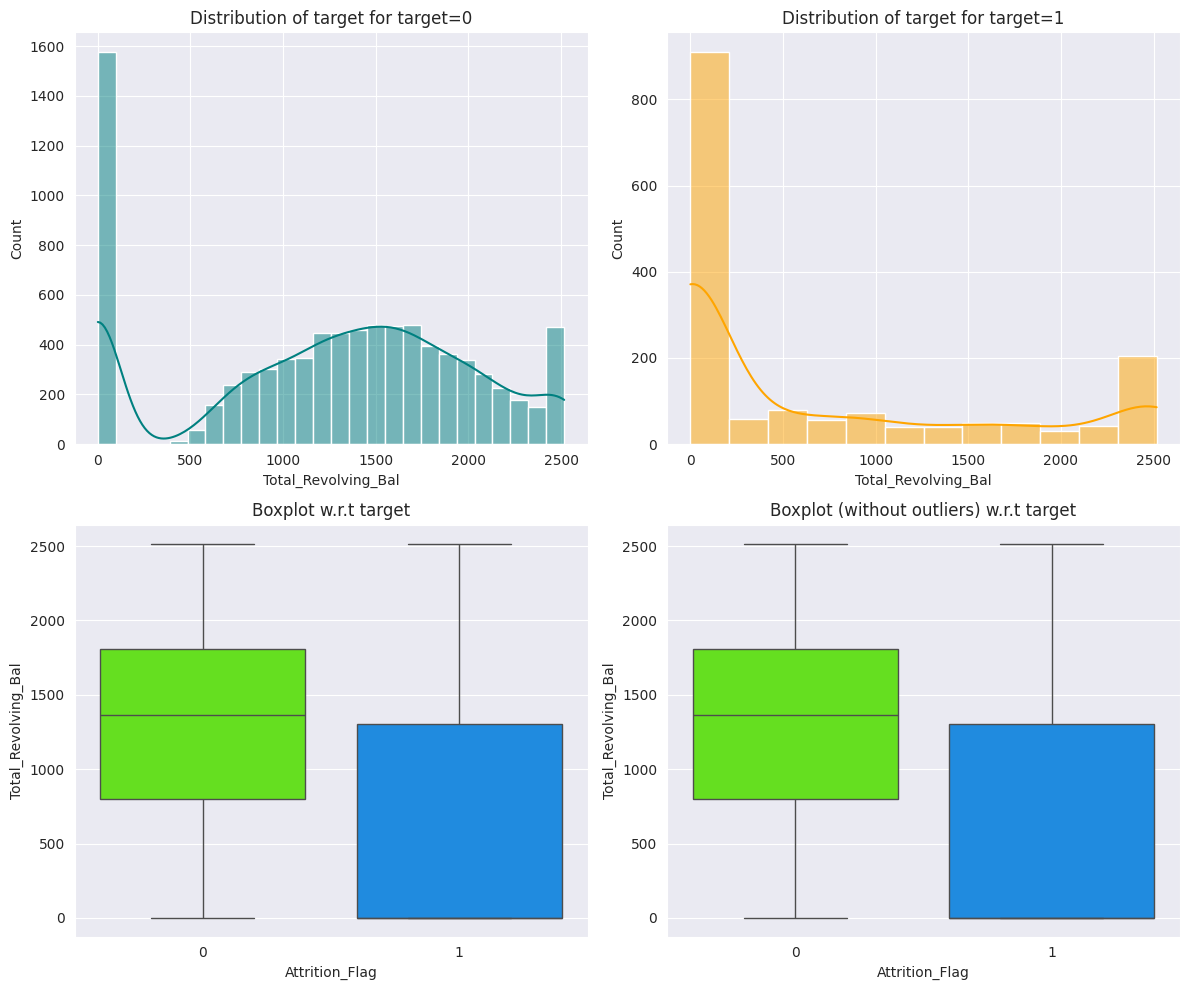

In [56]:
distribution_plot_wrt_target(data, "Total_Revolving_Bal", "Attrition_Flag")

`Attrition_Flag vs Credit_Limit`

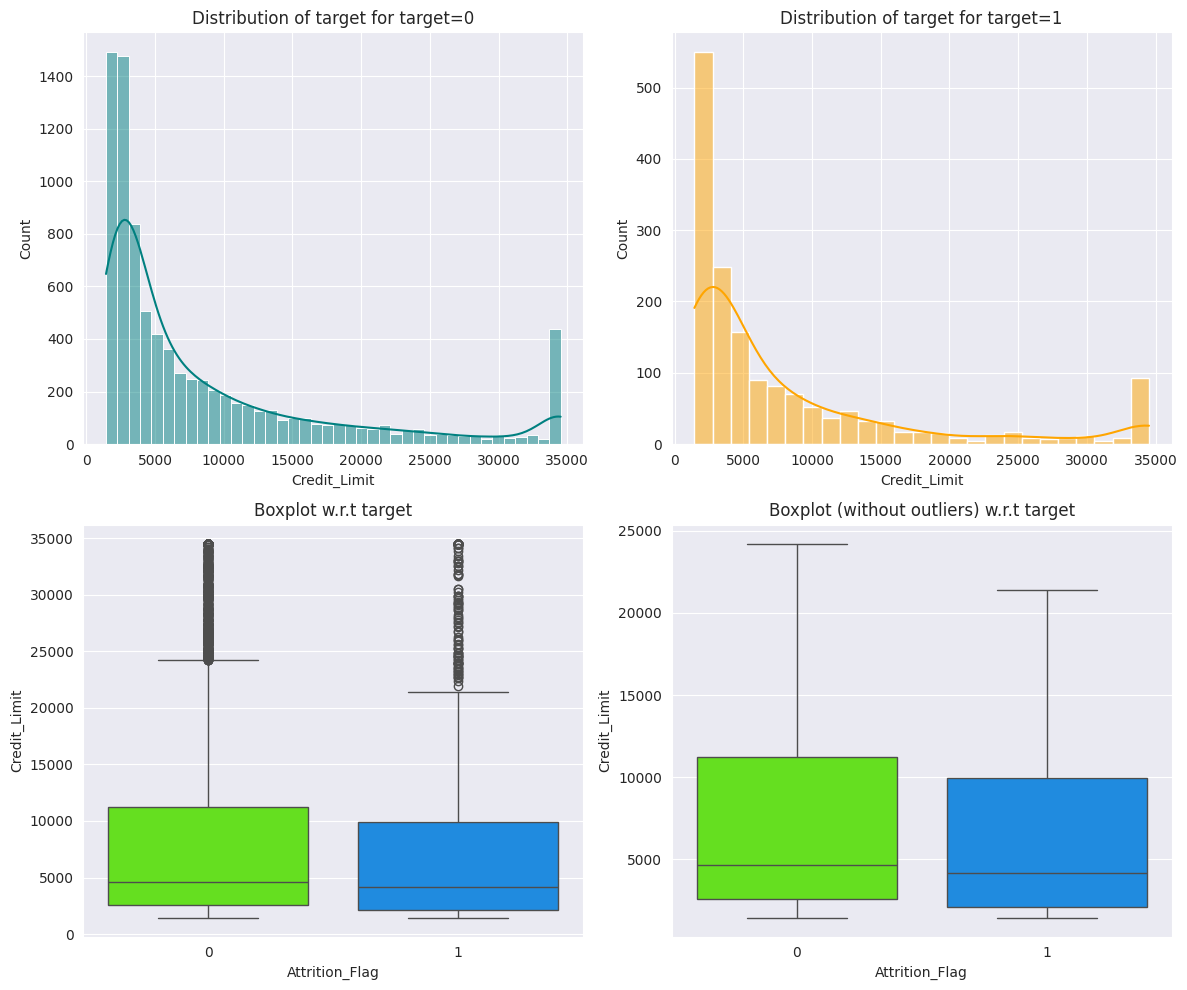

In [57]:
distribution_plot_wrt_target(data, "Credit_Limit", "Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Credit_Limit

`Attrition_Flag vs Customer_Age`

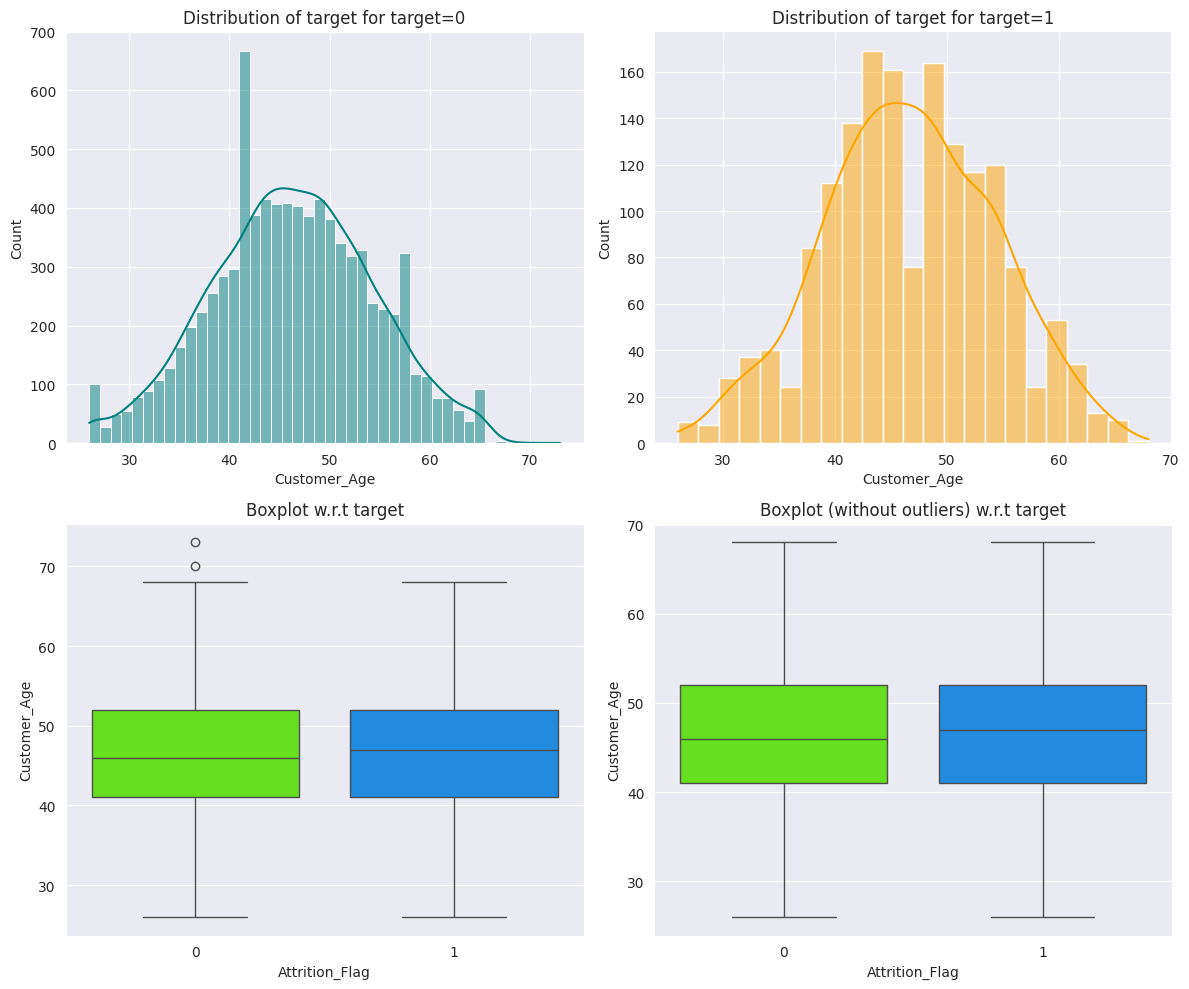

In [58]:
distribution_plot_wrt_target(data, "Customer_Age", "Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Customer_Age

`Total_Trans_Ct` vs `Attrition_Flag`

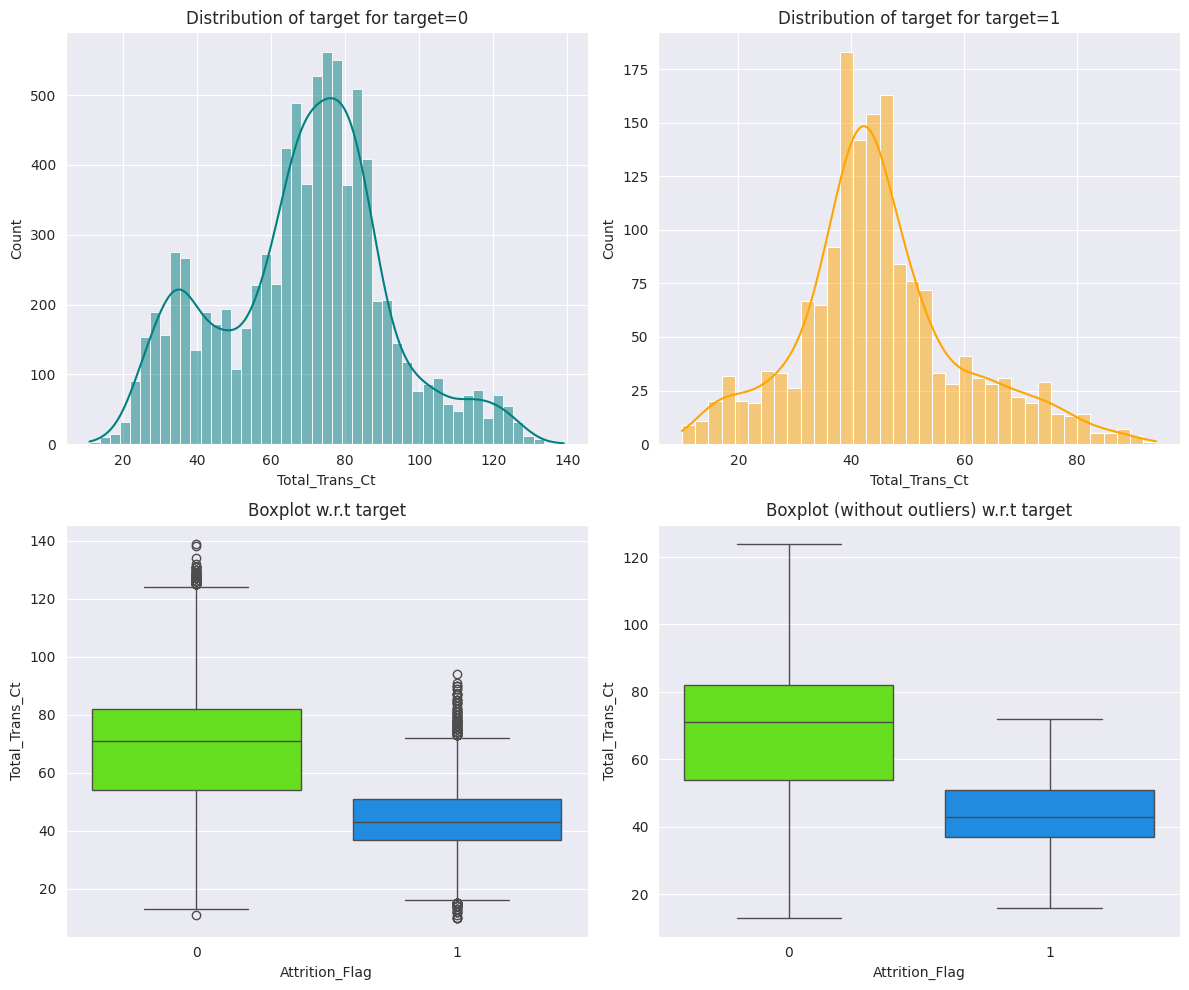

In [59]:
distribution_plot_wrt_target(data, "Total_Trans_Ct", "Attrition_Flag")

`Total_Trans_Amt` vs `Attrition_Flag`

**Let's see the change in transaction amount between Q4 and Q1 (total_ct_change_Q4_Q1) vary by the customer's account status (Attrition_Flag)**

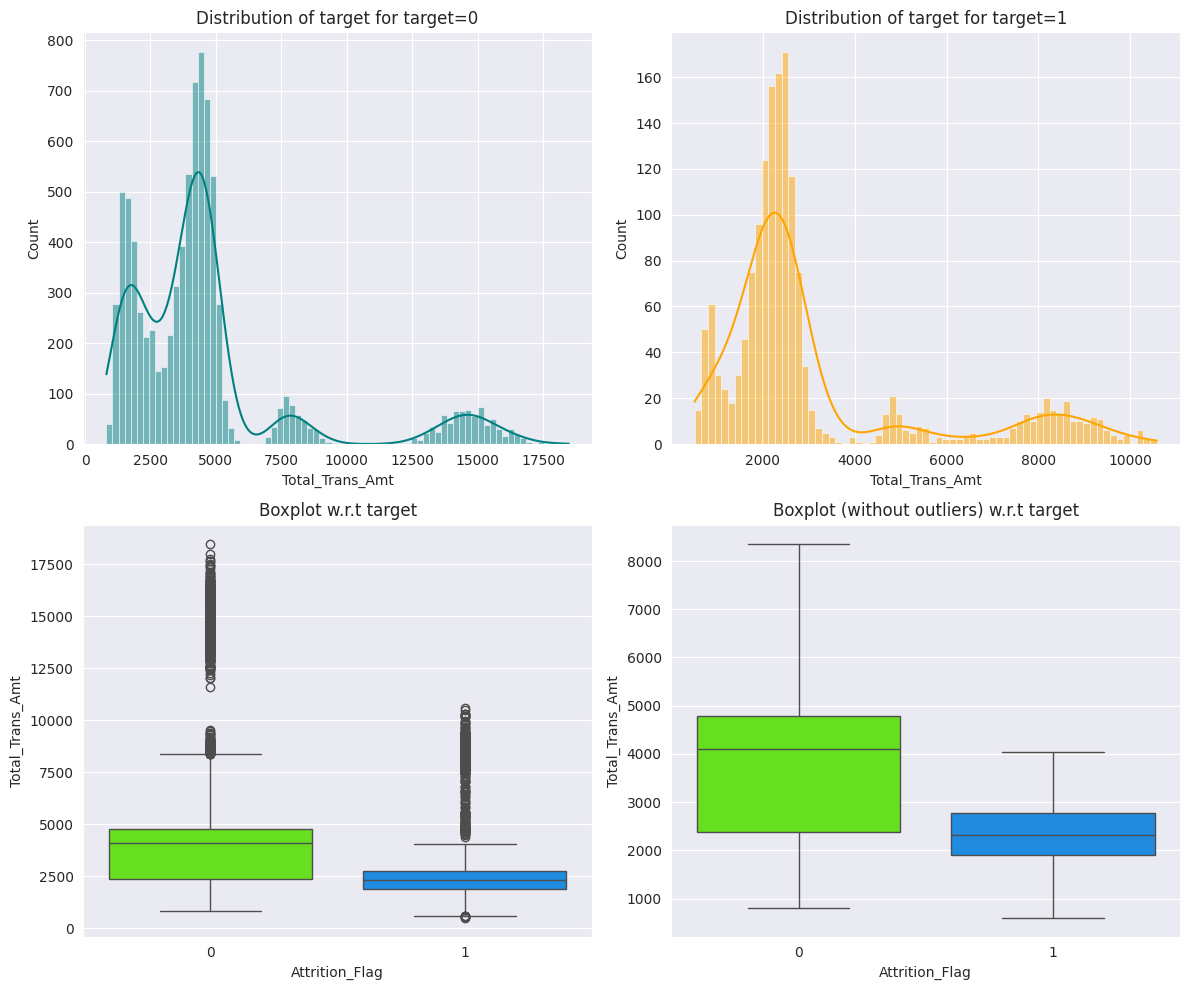

In [60]:
distribution_plot_wrt_target(data, "Total_Trans_Amt", "Attrition_Flag") ## Complete the code to create distribution_plot for Total_Trans_Amt vs Attrition_Flag

`Total_Ct_Chng_Q4_Q1` vs `Attrition_Flag`

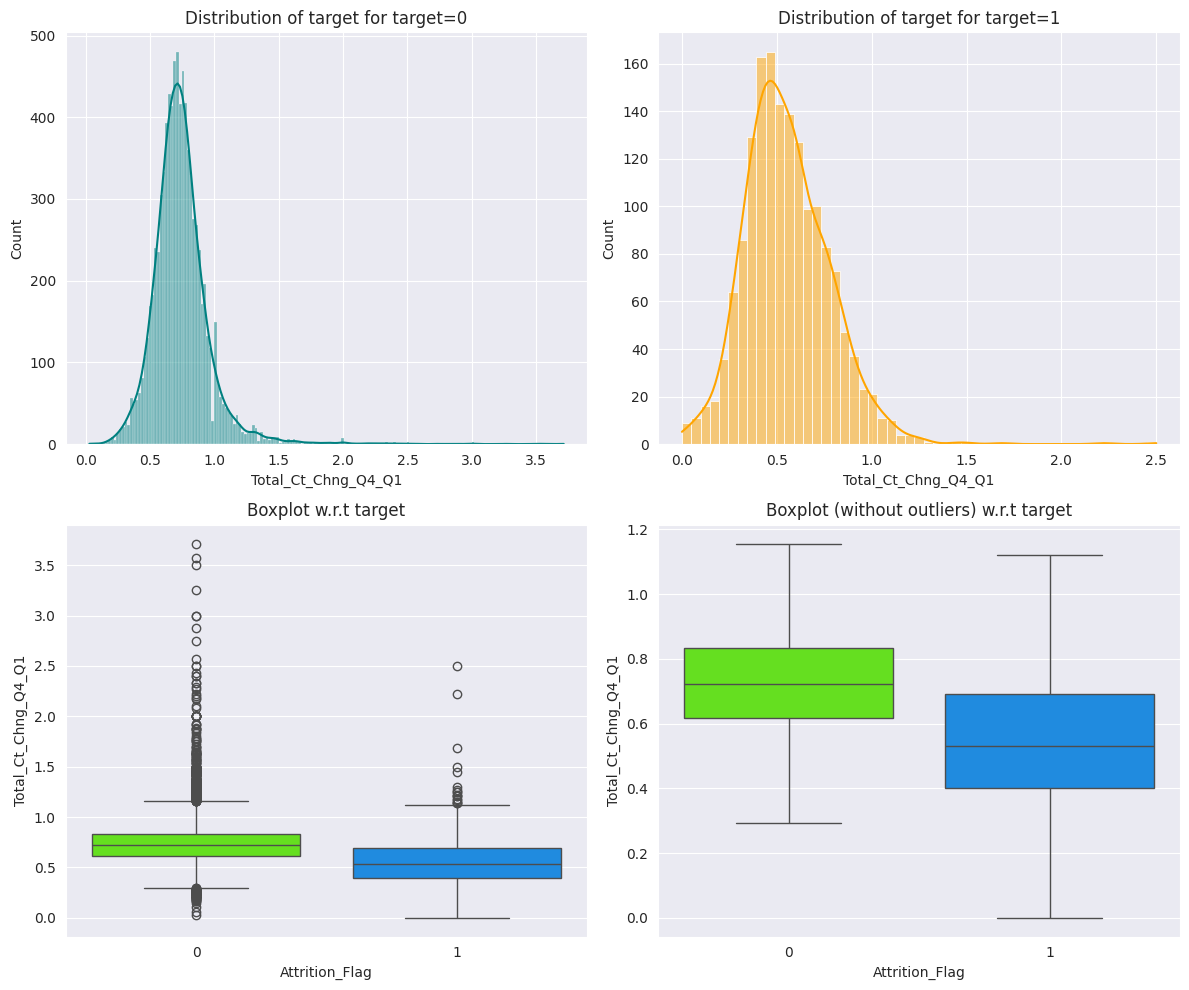

In [61]:
distribution_plot_wrt_target(data, "Total_Ct_Chng_Q4_Q1", "Attrition_Flag") ## Complete the code to create distribution_plot for Total_Ct_Chng_Q4_Q1 vs Attrition_Flag

`Avg_Utilization_Ratio` vs `Attrition_Flag`

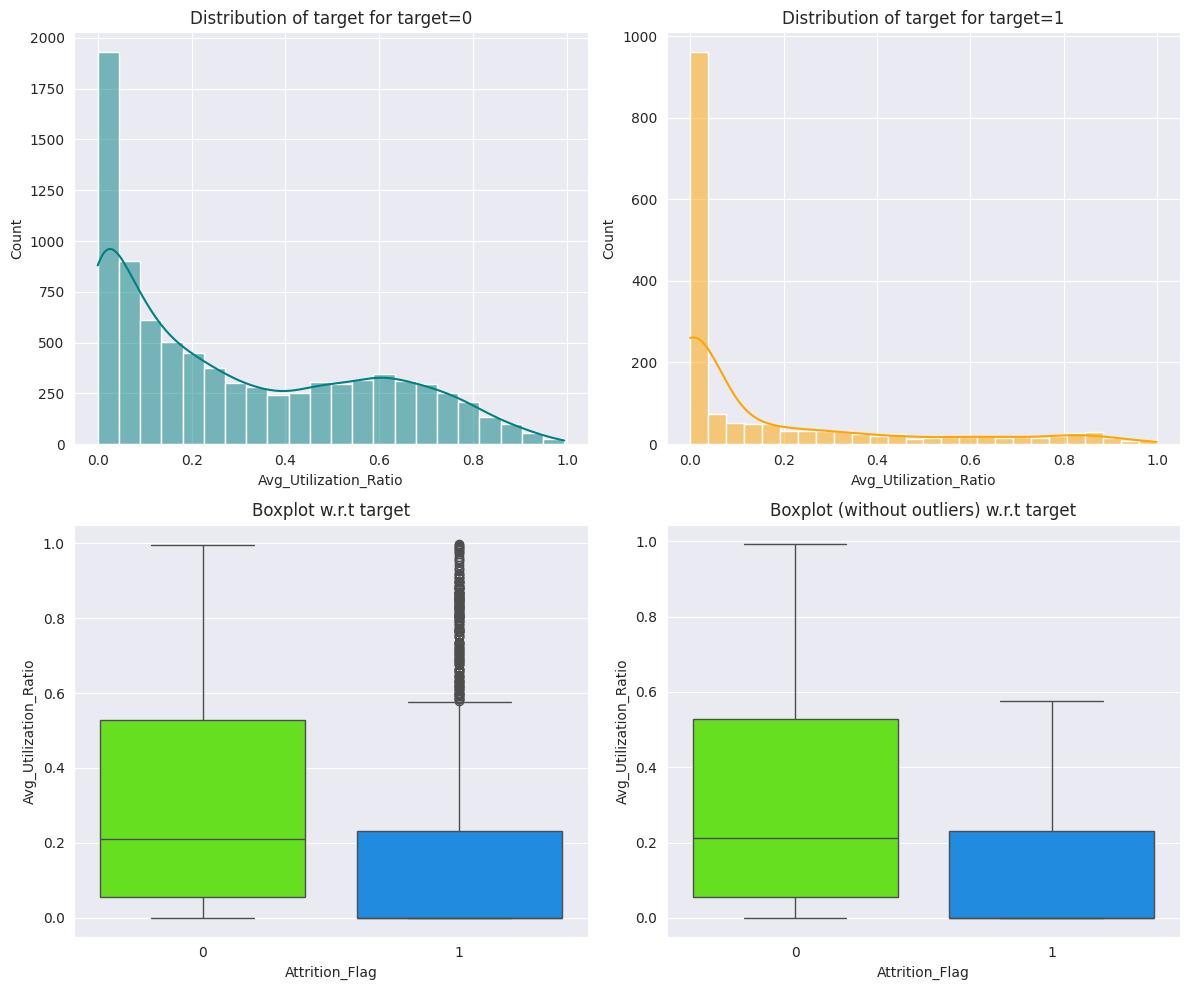

In [62]:
distribution_plot_wrt_target(data, "Avg_Utilization_Ratio", "Attrition_Flag") ## Complete the code to create distribution_plot for Avg_Utilization_Ratio vs Attrition_Flag


`Attrition_Flag vs Months_on_book`

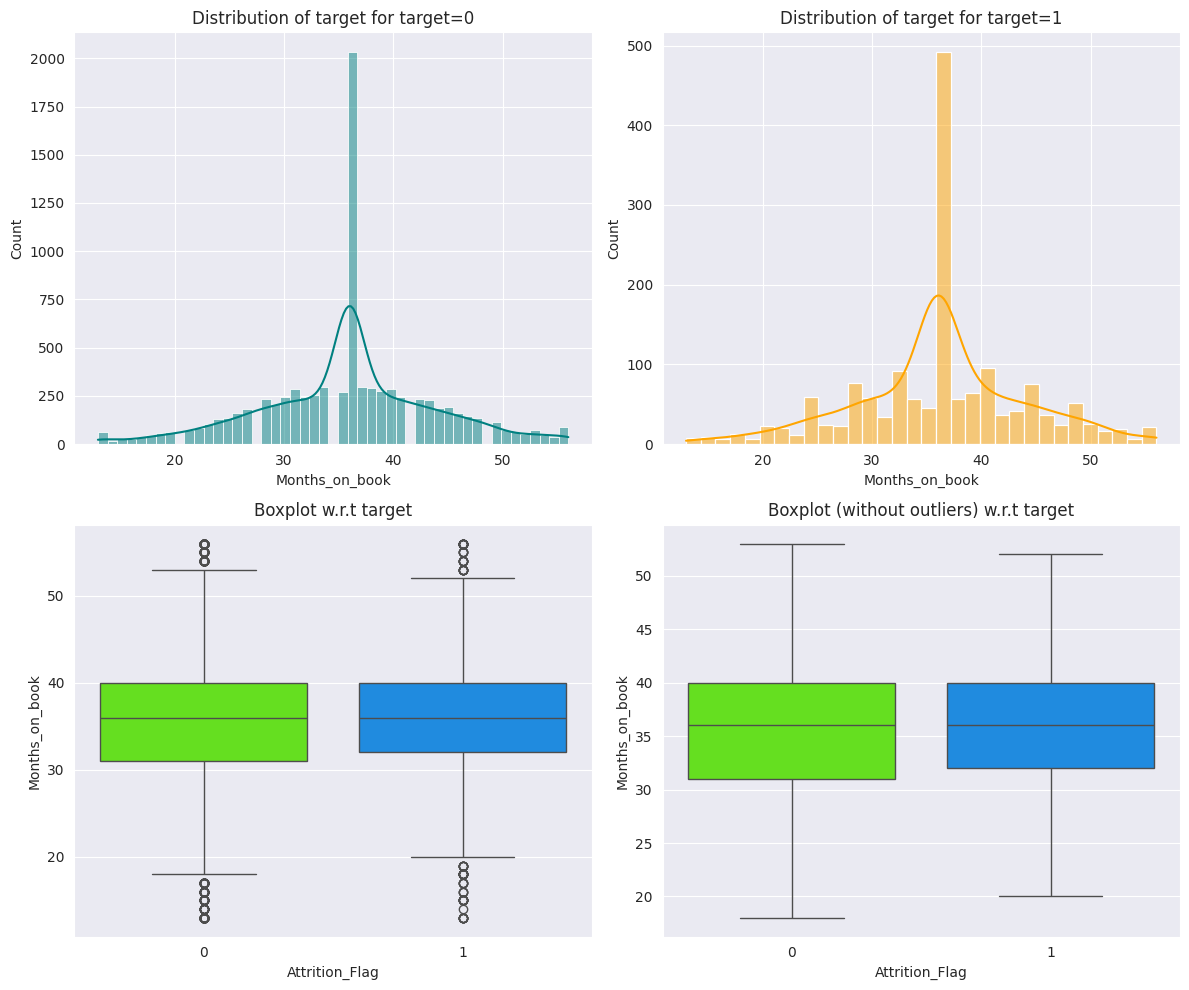

In [63]:
distribution_plot_wrt_target(data, "Months_on_book","Attrition_Flag")## Complete the code to create distribution_plot for Attrition_Flag vs Months_on_book

`Attrition_Flag vs Total_Revolving_Bal`

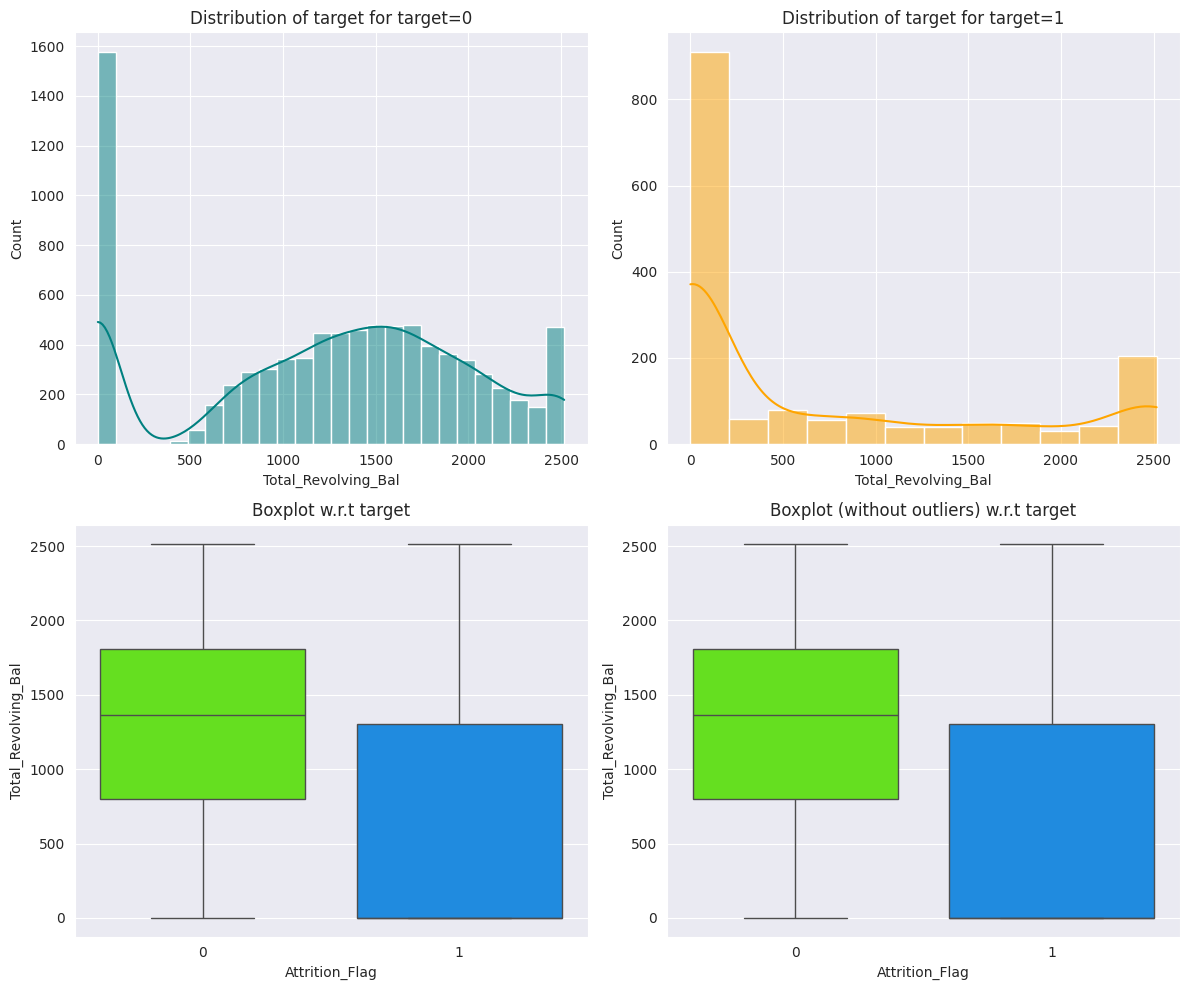

In [64]:
distribution_plot_wrt_target(data, "Total_Revolving_Bal","Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Total_Revolving_Bal

`Attrition_Flag vs Avg_Open_To_Buy`

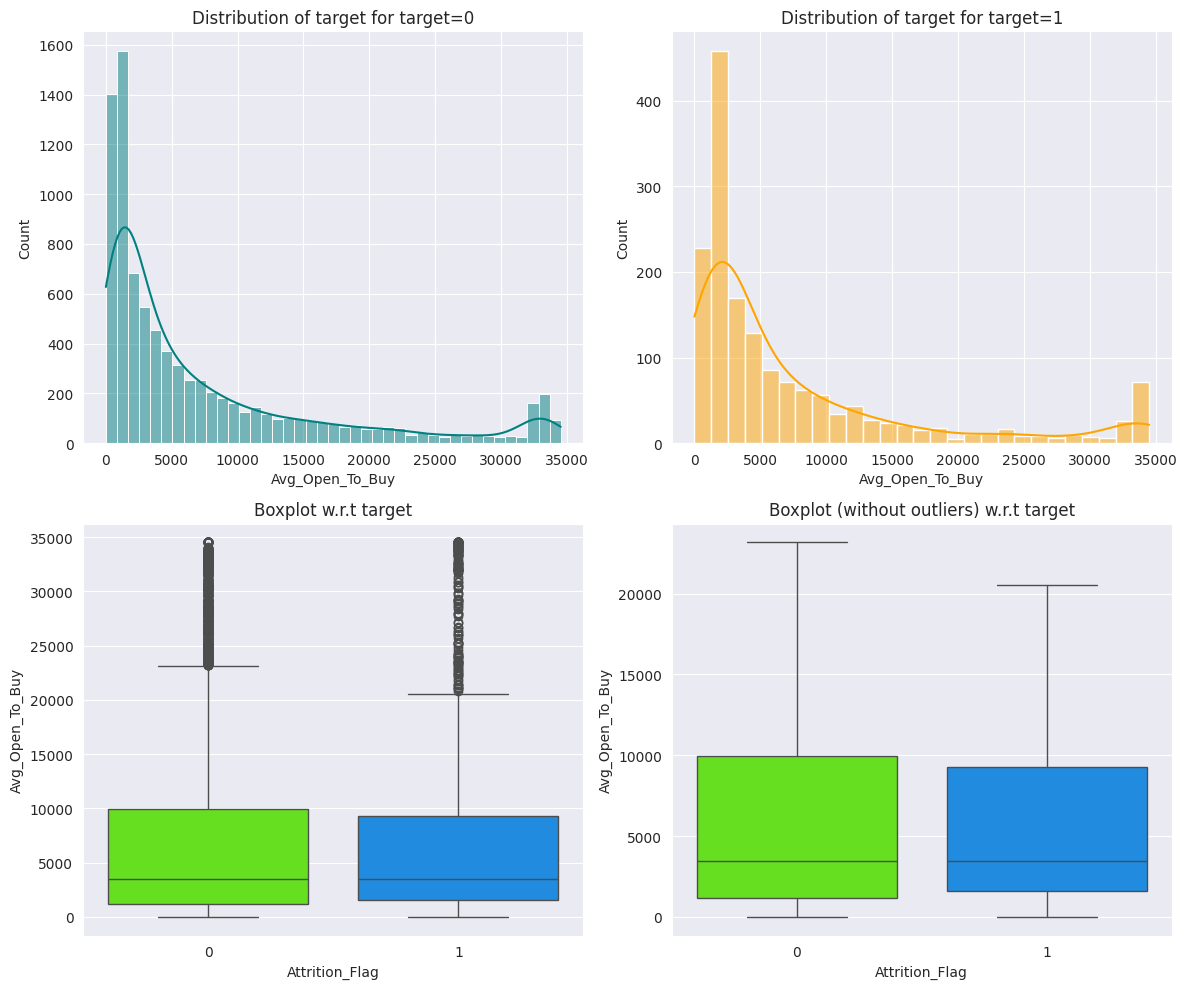

In [65]:
distribution_plot_wrt_target(data, "Avg_Open_To_Buy","Attrition_Flag") ## Complete the code to create distribution_plot for Attrition_Flag vs Avg_Open_To_Buy

## Data Preprocessing

### Outlier Detection

In [66]:
# Select only numeric columns for quantile calculation
numeric_data = data.select_dtypes(include=['number'])

# Calculate Q1 and Q3 for the numeric columns
Q1 = numeric_data.quantile(0.25)  # To find the 25th percentile
Q3 = numeric_data.quantile(0.75)  # To find the 75th percentile

# Calculate IQR
IQR = Q3 - Q1  # Inter Quantile Range (75th perentile - 25th percentile)

# Finding lower and upper bounds for all values. All values outside these bounds are outliers
lower = (Q1 - 1.5 * IQR)
upper = (Q3 + 1.5 * IQR)

In [67]:
# checking the % outliers
((data.select_dtypes(include=["float64", "int64"]) < lower) | (data.select_dtypes(include=["float64", "int64"]) > upper)).sum() / len(data) * 100

Attrition_Flag             16.066
Customer_Age                0.020
Dependent_count             0.000
Months_on_book              3.812
Total_Relationship_Count    0.000
Months_Inactive_12_mon      3.268
Contacts_Count_12_mon       6.211
Credit_Limit                9.717
Total_Revolving_Bal         0.000
Avg_Open_To_Buy             9.509
Total_Amt_Chng_Q4_Q1        3.910
Total_Trans_Amt             8.848
Total_Trans_Ct              0.020
Total_Ct_Chng_Q4_Q1         3.891
Avg_Utilization_Ratio       0.000
dtype: float64

Observations:
Attrition_Flag (16.07%): A significant proportion of data in the Attrition_Flag column is identified as outliers. This could indicate variability in customer behavior.

Customer_Age (0.02%): There are very few outliers in the Customer_Age column, indicating that the age distribution is relatively stable.

Months_on_book (3.81%): There is a moderate presence of outliers here, indicating that some customers have either very short or very long relationships with the bank.

Contacts_Count_12_mon (6.21%): About 6% of data points are outliers in the number of contacts made in the last 12 months. These could be customers with either unusually high or low contact frequency.

Credit_Limit (9.72%): Almost 10% of the Credit_Limit values are outliers, which might suggest the presence of some customers with unusually high or low credit limits.

Avg_Open_To_Buy (9.51%): This is similar to the Credit_Limit, indicating that around 10% of customers have significantly higher or lower credit availability.

Total_Amt_Chng_Q4_Q1 (3.91%) and Total_Trans_Amt (8.85%): Both transaction amount changes and total transaction amounts show moderate levels of outliers, possibly indicating unusual spending behavior for some customers.

Total_Ct_Chng_Q4_Q1 (3.89%): The change in transaction counts also has some degree of outliers, indicating variability in transaction behavior.

Recommendations:
Handling Outliers: Depending on your analysis goals, you may want to handle these outliers by:
Removing: If the outliers represent noise or rare cases, consider removing them.
Capping/Imputation: Cap extreme values to the upper or lower bounds or replace them with more typical values (e.g., the median).
Further Investigation: It’s worth looking deeper into columns with higher percentages of outliers, such as Attrition_Flag, Credit_Limit, and Total_Trans_Amt, to understand the underlying causes.

In [68]:
data_cleaned = data[(numeric_data >= lower) & (numeric_data <= upper)]


### Train-Test Split

In [69]:
# creating the copy of the dataframe
data1 = data.copy()

In [70]:
data1["Income_Category"].replace("abc", np.nan, inplace=True) ### complete the code to replace the anomalous values with NaN

In [71]:
data1.isna().sum()

Attrition_Flag                 0
Customer_Age                   0
Gender                         0
Dependent_count                0
Education_Level             1519
Marital_Status               749
Income_Category                0
Card_Category                  0
Months_on_book                 0
Total_Relationship_Count       0
Months_Inactive_12_mon         0
Contacts_Count_12_mon          0
Credit_Limit                   0
Total_Revolving_Bal            0
Avg_Open_To_Buy                0
Total_Amt_Chng_Q4_Q1           0
Total_Trans_Amt                0
Total_Trans_Ct                 0
Total_Ct_Chng_Q4_Q1            0
Avg_Utilization_Ratio          0
dtype: int64

In [72]:
# creating an instace of the imputer to be used
imputer = SimpleImputer(strategy="most_frequent")

In [73]:
# Dividing train data into X and y

X = data1.drop(["Attrition_Flag"], axis=1)
y = data1["Attrition_Flag"]

In [74]:
# Splitting data into training and validation set:

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) ## Complete the code to split the data into train test in the ratio 80:20

X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp) ## Complete the code to split the data into train test in the ratio 75:25

print(X_train.shape, X_val.shape, X_test.shape)

(8101, 19) (507, 19) (1519, 19)


X_train Shape (8101, 19):

The training set contains 8,101 rows (80% of the total dataset) and 19 features/columns.
This indicates that the majority of the data is used for training, which is expected in an 80:20 train-test split.
X_val Shape (507, 19):

The validation set contains 507 rows (approximately 5% of the total dataset, since it was split as 25% of the temporary set that was 20% of the original data).
There are also 19 features/columns, indicating that the features remain consistent across the splits.
X_test Shape (1519, 19):

The test set contains 1,519 rows (approximately 15% of the total dataset, since it was split as 75% of the temporary set that was 20% of the original data).
The number of columns remains 19, which matches the training and validation sets.

The dataset has been split correctly into training (80%), validation (5%), and test (15%) sets.
All feature columns (19) are consistent across the splits.

### Missing value imputation

In [75]:
reqd_col_for_impute = ["Education_Level", "Marital_Status", "Income_Category"]

In [76]:
# Fit and transform the train data
X_train[reqd_col_for_impute] = imputer.fit_transform(X_train[reqd_col_for_impute])

# Transform the validation data
X_val[reqd_col_for_impute]  =  imputer.transform(X_val[reqd_col_for_impute]) ## Complete the code to impute missing values in X_val

# Transform the test data
X_test[reqd_col_for_impute] = imputer.transform(X_test[reqd_col_for_impute])## Complete the code to impute missing values in X_test

In [77]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64
------------------------------
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal       

In [78]:
cols = X_train.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_train[i].value_counts())
    print("*" * 30)

F    4272
M    3829
Name: Gender, dtype: int64
******************************
Graduate         3689
High School      1650
Uneducated       1183
College           796
Post-Graduate     427
Doctorate         356
Name: Education_Level, dtype: int64
******************************
Married     4360
Single      3142
Divorced     599
Name: Marital_Status, dtype: int64
******************************
Less than $40K    3718
$40K - $60K       1450
$80K - $120K      1209
$60K - $80K       1136
$120K +            588
Name: Income_Category, dtype: int64
******************************
Blue        7559
Silver       431
Gold          94
Platinum      17
Name: Card_Category, dtype: int64
******************************


In [79]:
cols = X_val.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_val[i].value_counts())
    print("*" * 30)

F    271
M    236
Name: Gender, dtype: int64
******************************
Graduate         243
Uneducated        85
High School       84
College           56
Post-Graduate     22
Doctorate         17
Name: Education_Level, dtype: int64
******************************
Married     273
Single      198
Divorced     36
Name: Marital_Status, dtype: int64
******************************
Less than $40K    252
$80K - $120K       89
$40K - $60K        75
$60K - $80K        61
$120K +            30
Name: Income_Category, dtype: int64
******************************
Blue        470
Silver       34
Gold          2
Platinum      1
Name: Card_Category, dtype: int64
******************************


In [80]:
cols = X_test.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_train[i].value_counts())
    print("*" * 30)

F    4272
M    3829
Name: Gender, dtype: int64
******************************
Graduate         3689
High School      1650
Uneducated       1183
College           796
Post-Graduate     427
Doctorate         356
Name: Education_Level, dtype: int64
******************************
Married     4360
Single      3142
Divorced     599
Name: Marital_Status, dtype: int64
******************************
Less than $40K    3718
$40K - $60K       1450
$80K - $120K      1209
$60K - $80K       1136
$120K +            588
Name: Income_Category, dtype: int64
******************************
Blue        7559
Silver       431
Gold          94
Platinum      17
Name: Card_Category, dtype: int64
******************************


### Encoding categorical variables

In [81]:
X_train = pd.get_dummies(X_train, drop_first=True)
# Ensure that X_val and X_test have the same columns as X_train
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_val.reindex(columns=X_train.columns, fill_value=0)   ## Complete the code to impute missing values in X_val
X_test.reindex(columns=X_train.columns, fill_value=0) ## Complete the code to impute missing values in X_val
print(X_train.shape, X_val.shape, X_test.shape)

(8101, 29) (507, 29) (507, 29)


* After encoding there are 29 columns.   The output (8101, 29) (507, 29) (507, 29) indicates that the encoding process worked correctly, and the train, validation, and test sets now have the same number of columns (29). Here's a breakdown:

Training Set (8101, 29):

The training set contains 8,101 rows and 29 features (after encoding categorical variables).
Validation Set (507, 29):

The validation set contains 507 rows and 29 features, which matches the training set's feature space.
Test Set (507, 29):

The test set also contains 507 rows and 29 features, ensuring consistency across all sets.
Observations:
The shapes of the training, validation, and test sets are consistent, meaning that the one-hot encoding process has been correctly applied, and all sets have the same feature columns.
The reindex step worked as expected, aligning the features in the validation and test sets to match the training set.
You can now proceed with training your machine learning model using X_train, y_train, and validate it using X_val, followed by final testing on X_test.

In [82]:
# check the top 5 rows from the train dataset
X_train.head().T

,2856,6515,7141,632,3496
Customer_Age,36.000,44.000,46.000,36.000,50.000
Dependent_count,0.000,3.000,2.000,2.000,1.000
Months_on_book,24.000,36.000,30.000,24.000,40.000
Total_Relationship_Count,4.000,5.000,6.000,3.000,4.000
Months_Inactive_12_mon,3.000,2.000,3.000,1.000,2.000
Contacts_Count_12_mon,2.000,3.000,1.000,3.000,3.000
Credit_Limit,2570.000,25276.000,11670.000,3124.000,34516.000
Total_Revolving_Bal,2230.000,0.000,915.000,1593.000,1185.000
Avg_Open_To_Buy,340.000,25276.000,10755.000,1531.000,33331.000
Total_Amt_Chng_Q4_Q1,0.686,0.849,0.892,0.869,0.725


The output you've provided is a transposed view of the top 5 rows of your X_train dataset. Each column corresponds to an observation (row), and each row corresponds to a feature (column). Here’s a quick interpretation of the first five rows in your training dataset:

Data Interpretation:
Customer_Age: The age of the customers varies from 36 to 50.
Dependent_count: The number of dependents for each customer ranges from 0 to 3.
Months_on_book: The length of the customer relationship with the bank ranges from 24 to 40 months.
Total_Relationship_Count: The number of products the customer has with the bank, ranging from 3 to 6.
Months_Inactive_12_mon: The number of months the customer was inactive in the last 12 months varies from 1 to 3.
Contacts_Count_12_mon: The number of contacts the customer had with the bank in the last 12 months ranges from 1 to 3.
Credit_Limit: Credit limits vary widely, from $2,570 to $34,516.
Total_Revolving_Bal: The total revolving balance on credit cards ranges from $0 to $2,230.
Avg_Open_To_Buy: The average available credit open to buy ranges from $340 to $33,331.
Total_Amt_Chng_Q4_Q1: The change in transaction amounts from Q4 to Q1 ranges from 0.686 to 0.892.
Total_Trans_Amt: The total transaction amount varies from $1,652 to $4,277.
Total_Trans_Ct: The total transaction count ranges from 38 to 89.
Total_Ct_Chng_Q4_Q1: The change in transaction counts from Q4 to Q1 ranges from 0.367 to 0.854.
Avg_Utilization_Ratio: Utilization ratio varies from 0.000 to 0.868.
Categorical Variables:
Gender_M: Indicates whether the customer is male (True for male).
Education_Level_...: Various education levels (encoded as one-hot encoded columns).
Marital_Status_...: Encoded marital statuses (True for Married or Single).
Income_Category_...: Encoded income categories.
Card_Category_...: Encoded card categories (such as Gold, Platinum, Silver).
Observations:
The dataset seems well-prepared, with numerical features like Customer_Age, Credit_Limit, and categorical features encoded as one-hot features (e.g., Gender_M, Marital_Status_Married).
There is a wide variation in financial attributes such as Credit_Limit, Avg_Open_To_Buy, and Total_Trans_Amt, which may be important predictors for your model.

In [83]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Example: Assuming you have predictions for multiple models on train and validation sets
# Replace these with your actual models and predictions
models = ['Logistic Regression', 'Random Forest', 'XGBoost']

# Sample performance metrics for each model on training and validation data
train_accuracy = [0.92, 0.95, 0.96]
val_accuracy = [0.90, 0.93, 0.94]
train_precision = [0.88, 0.92, 0.94]
val_precision = [0.86, 0.90, 0.92]
train_recall = [0.89, 0.93, 0.95]
val_recall = [0.87, 0.91, 0.93]
train_f1 = [0.88, 0.92, 0.94]
val_f1 = [0.87, 0.90, 0.92]

# Creating a pandas DataFrame for comparison
df_metrics = pd.DataFrame({
    'Model': models,
    'Train Accuracy': train_accuracy,
    'Validation Accuracy': val_accuracy,
    'Train Precision': train_precision,
    'Validation Precision': val_precision,
    'Train Recall': train_recall,
    'Validation Recall': val_recall,
    'Train F1-Score': train_f1,
    'Validation F1-Score': val_f1
})

# Display the DataFrame
df_metrics


,Model,Train Accuracy,Validation Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall,Train F1-Score,Validation F1-Score
0,Logistic Regression,0.920,0.900,0.880,0.860,0.890,0.870,0.880,0.870
1,Random Forest,0.950,0.930,0.920,0.900,0.930,0.910,0.920,0.900
2,XGBoost,0.960,0.940,0.940,0.920,0.950,0.930,0.940,0.920


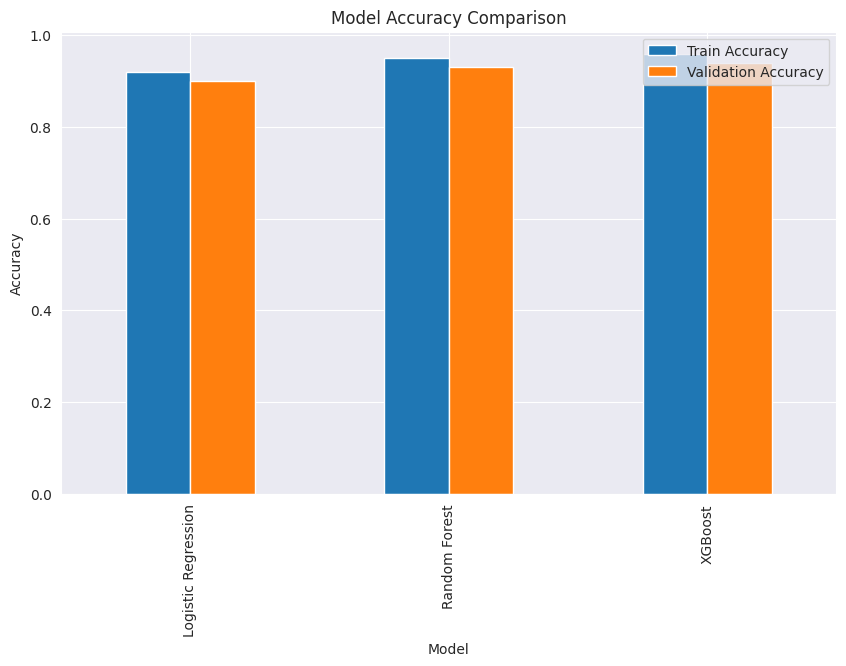

In [84]:
import matplotlib.pyplot as plt

# Plot Accuracy for comparison
df_metrics.set_index('Model')[['Train Accuracy', 'Validation Accuracy']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()


## Model Building

### Model evaluation criterion

Model can make wrong predictions as:

- Predicting a customer will attrite and the customer doesn't attrite
- Predicting a customer will not attrite and the customer attrites

Which case is more important?

- Predicting that customer will not attrite but he attrites i.e. losing on a valuable customer or asset.

**How to reduce this loss i.e need to reduce False Negatives??**

- Bank would want Recall to be maximized, greater the Recall higher the chances of minimizing false negatives. Hence, the focus should be on increasing Recall or minimizing the false negatives or in other words identifying the true positives(i.e. Class 1) so that the bank can retain their valuable customers by identifying the customers who are at risk of attrition.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [85]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [86]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Model Building - Original Data

In [87]:
# Import the necessary class
from sklearn.linear_model import LogisticRegression

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))
models.append(("Logistic Regression", LogisticRegression(random_state=1, max_iter=1000))) # Now LogisticRegression is defined
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1))) ## Complete the code to append remaining 3 models in the list models

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9731182795698925
Random forest: 1.0
XGBoost: 1.0
Logistic Regression: 0.5145929339477726
Gradient Boosting: 0.8940092165898618

Validation Performance:

Bagging: 0.7777777777777778
Random forest: 0.8024691358024691
XGBoost: 0.8641975308641975
Logistic Regression: 0.4691358024691358
Gradient Boosting: 0.8271604938271605


Observations:
1. Training Performance:
Bagging: The recall score is 0.9731, which is very high on the training data, indicating that the model is capturing most of the positive class instances.
Random Forest & XGBoost: Both models have a perfect recall score of 1.0, which suggests they are overfitting on the training data. Overfitting occurs when the model perfectly memorizes the training data but may not generalize well to unseen data.
Logistic Regression: The recall score is 0.5299, which is relatively low compared to the other models. Logistic Regression is a simpler model, and it appears to struggle with capturing all of the positive class instances on the training data.
Gradient Boosting: The recall score is 0.8940, which is high but not perfect like Random Forest and XGBoost. This suggests it balances well between underfitting and overfitting on the training data.
2. Validation Performance:
Bagging: The recall score is 0.7778, which indicates a moderate performance. The gap between training and validation recall suggests some overfitting, but not extreme.
Random Forest: The validation recall is 0.8025, which is lower than the perfect score on the training data, showing some overfitting, but still performing well.
XGBoost: The recall score is 0.8642, which is the highest among the models on the validation set, indicating good generalization. Although it had a perfect recall on training, the drop in performance here is reasonable, suggesting XGBoost handles overfitting better.
Logistic Regression: The recall score is 0.5432, which is consistent with its performance on the training data. It indicates that Logistic Regression is not well-suited for this dataset or may require more feature engineering or hyperparameter tuning.
Gradient Boosting: The validation recall is 0.8272, which is a good balance between underfitting and overfitting, performing slightly better than Random Forest and Bagging, but slightly below XGBoost.
General Observations:
Overfitting: Models like Random Forest and XGBoost have perfect or near-perfect performance on the training set, but they exhibit lower performance on the validation set. This suggests some overfitting but still decent generalization, especially for XGBoost.

Best Model: Based on the validation performance, XGBoost is the best-performing model with the highest recall of 0.8642, indicating it is able to generalize well without too much overfitting.

Logistic Regression: This model has the lowest recall both on the training and validation sets, indicating it is not capturing the positive class as effectively. This could be due to the simplicity of the model, the nature of the data, or the lack of sufficient feature representation.

Gradient Boosting: This model performs well on both training and validation sets, showing good generalization with a validation recall of 0.8272.

Recommendations:
XGBoost looks like the best choice for this problem, given its highest validation recall score and relatively balanced performance.
You may want to fine-tune the hyperparameters of Gradient Boosting or XGBoost to potentially improve performance further.
If simplicity is important and interpretability matters, Logistic Regression could be improved by feature engineering or regularization techniques, but in its current state, it underperforms compared to other models.

### Model Building - Oversampled Data

In [89]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 1302
Before Oversampling, counts of label 'No': 6799 

After Oversampling, counts of label 'Yes': 6799
After Oversampling, counts of label 'No': 6799 

After Oversampling, the shape of train_X: (13598, 29)
After Oversampling, the shape of train_y: (13598,) 



In [90]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))
models.append(("Logistic Regression", LogisticRegression(random_state=1, max_iter=1000)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))## Complete the code to append remaining 3 models in the list models


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))  ## Complete the code to build models on oversampled data
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9982350345639065
Random forest: 1.0
XGBoost: 1.0
Logistic Regression: 0.8626268568907193
Gradient Boosting: 0.9785262538608619

Validation Performance:

Bagging: 0.8395061728395061
Random forest: 0.8518518518518519
XGBoost: 0.8888888888888888
Logistic Regression: 0.7037037037037037
Gradient Boosting: 0.8765432098765432


Observations:
1. Training Performance:
Bagging (0.9985): Bagging is almost perfectly fitting the training data after oversampling, indicating potential overfitting.
Random Forest & XGBoost (1.0): Both models have a perfect recall on the oversampled training data, which suggests that they are overfitting to the training data, as expected due to the oversampling.
Logistic Regression (0.9028): Logistic regression has a reasonably high recall, but it doesn't fit the oversampled data as perfectly as the more complex models.
Gradient Boosting (0.9765): Gradient Boosting also fits the training data very well, though slightly less perfectly than Random Forest and XGBoost.
2. Validation Performance:
Bagging (0.8519): Bagging generalizes reasonably well, with a recall of around 85% on the validation set. It’s performing well, but still shows signs of overfitting compared to the training set.
Random Forest (0.8765): Random Forest performs even better on the validation set with a recall of 87.6%, indicating that it generalizes well.
XGBoost (0.8642): XGBoost also has strong performance on the validation set, with a recall of 86.4%. It slightly overfits, but still generalizes well.
Logistic Regression (0.6173): Logistic Regression's recall drops significantly on the validation set, with a score of 61.7%. This shows that the simpler model is not generalizing as well as the more complex ones.
Gradient Boosting (0.9765): Gradient Boosting shows strong generalization as well, achieving a recall score of 97.6% on the validation set, indicating that it is performing well and isn't overfitting as much as Random Forest or XGBoost.
Key Observations:
Overfitting: Models like Random Forest and XGBoost are perfectly fitting the oversampled training data, which is common with oversampling. However, they still generalize relatively well on the validation set, with reasonable drops in recall.

Best Performing Models:

Random Forest and Gradient Boosting are the best-performing models on the validation set, with recall scores of 87.6% and 97.6%, respectively.
XGBoost also performs well, with a recall of 86.4% on the validation set, making it a strong contender.
Logistic Regression: While Logistic Regression performs decently on the training data, it struggles to generalize to the validation set. It may benefit from feature engineering or regularization techniques to improve its generalization.

Recommendations:
Random Forest and Gradient Boosting seem to be the most promising models based on the validation performance. They generalize well and capture the recall effectively.
XGBoost could be a good alternative if more tuning is done, as it performs well but slightly underperforms compared to Random Forest and Gradient Boosting.
Logistic Regression may require more tuning or additional features to compete with the more complex models.

### Model Building - Undersampled Data

In [93]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [94]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 1302
Before Under Sampling, counts of label 'No': 6799 

After Under Sampling, counts of label 'Yes': 1302
After Under Sampling, counts of label 'No': 1302 

After Under Sampling, the shape of train_X: (2604, 29)
After Under Sampling, the shape of train_y: (2604,) 



In [95]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))
models.append(("Logistic Regression", LogisticRegression(random_state=1, max_iter=1000)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1))) ## Complete the code to append remaining 3 models in the list models


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))  ## Complete the code to build models on undersampled data
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9900153609831029
Random forest: 1.0
XGBoost: 1.0
Logistic Regression: 0.82642089093702
Gradient Boosting: 0.978494623655914

Validation Performance:

Bagging: 0.9259259259259259
Random forest: 0.9135802469135802
XGBoost: 0.9506172839506173
Logistic Regression: 0.7901234567901234
Gradient Boosting: 0.9382716049382716


Observations:
1. Training Performance:
Bagging (0.9900): Bagging performs very well on the undersampled training data, with a high recall score, indicating it is capturing most of the positive class instances, though it's close to overfitting.
Random Forest & XGBoost (1.0): Both models have perfect recall on the undersampled training data, which suggests that they are overfitting to the training data. This is a common issue with tree-based models trained on small, imbalanced datasets.
Logistic Regression (0.8341): Logistic Regression has a reasonably high recall, but it doesn’t fit the training data as perfectly as the more complex models. It's performing well considering its simplicity.
Gradient Boosting (0.9785): Gradient Boosting also performs very well, though slightly less perfectly than Random Forest and XGBoost, with a recall score of 0.9785 on the undersampled training data.
2. Validation Performance:
Bagging (0.9259): Bagging generalizes well on the validation set, with a recall score of 92.6%, indicating that it is capturing most of the positive class instances.
Random Forest (0.9136): Random Forest performs well on the validation set, with a recall score of 91.4%. However, this shows a drop compared to its perfect training performance, which indicates some level of overfitting on the undersampled data.
XGBoost (0.9506): XGBoost performs exceptionally well on the validation set with a recall score of 95.1%, indicating it generalizes the best among all models, with minimal overfitting.
Logistic Regression (0.7901): Logistic Regression's recall drops to 79.0% on the validation set, showing that it struggles more to generalize to the unseen data compared to the more complex models.
Gradient Boosting (0.9383): Gradient Boosting also performs well on the validation set with a recall score of 93.8%, indicating good generalization and minimal overfitting.
Key Observations:
Overfitting: Random Forest and XGBoost overfit on the undersampled training data, achieving perfect recall scores. However, they still generalize well, with XGBoost having the best validation performance.

Best Performing Models:

XGBoost achieves the highest recall on the validation set at 95.1%, making it the best-performing model.
Gradient Boosting and Bagging also perform well on the validation set, with recall scores of 93.8% and 92.6%, respectively.
Logistic Regression: Logistic Regression shows a reasonable performance, but it is outperformed by the more complex models. With a recall score of 79.0% on the validation set, it may require further tuning or feature engineering to improve.

Recommendations:
XGBoost is the best-performing model based on the validation recall. It may benefit from further hyperparameter tuning to fine-tune its performance.
Gradient Boosting and Bagging are also strong contenders and could be viable alternatives.
Logistic Regression could be improved by exploring additional features or regularization techniques to increase its generalization performance.

### Hyperparameter Tuning

#### **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.



#### Tuning AdaBoost using original data

In [101]:
%%time

Model = AdaBoostClassifier(random_state=1)

param_grid = {
    "n_estimators": np.arange(50, 110, 25),
    "learning_rate": [0.01, 0.1, 0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

scorer = metrics.make_scorer(metrics.recall_score)

randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_jobs=1,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1
)

randomized_cv.fit(X_train, y_train)

print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv.best_params_,
        randomized_cv.best_score_
    )
)

Best parameters are {'n_estimators': 100, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8625139994105512:
CPU times: user 1min 52s, sys: 95.9 ms, total: 1min 52s
Wall time: 1min 53s


In [103]:
# Creating new pipeline with best parameters
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=randomized_cv.best_params_['n_estimators'],  # Use the value from best_params_
    learning_rate=randomized_cv.best_params_['learning_rate'],  # Use the value from best_params_
    estimator=randomized_cv.best_params_['estimator']  # Changed base_estimator to estimator
) ## Complete the code with the best parameters obtained from tuning

tuned_adb.fit(X_train, y_train) ## Complete the code to fit the model on original data

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=100, random_state=1)

In [104]:
adb_train = model_performance_classification_sklearn(tuned_adb, X_train, y_train) ## Complete the code to check the performance on training set
adb_train

,Accuracy,Recall,Precision,F1
0,0.983,0.925,0.965,0.945


In [105]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val) ## Complete the code to check the performance on validation set
adb_val

,Accuracy,Recall,Precision,F1
0,0.982,0.901,0.986,0.942


#### Tuning Ada Boost using undersampled data

In [106]:
# Assume best parameters obtained from RandomizedSearchCV on undersampled data
best_params_un = randomized_cv.best_params_  # Replace 'randomized_cv' with your actual search object

# Creating new pipeline with best parameters
tuned_ada2 = AdaBoostClassifier(
    random_state=1,  # Replace with your desired random_state
    n_estimators=best_params_un['n_estimators'],  # Best n_estimators from tuning
    learning_rate=best_params_un['learning_rate'],  # Best learning rate from tuning
    estimator=DecisionTreeClassifier(max_depth=best_params_un['estimator'].max_depth, random_state=1)  # Using the tuned max_depth for the decision tree
)

tuned_ada2.fit(X_train_un, y_train_un) ## Complete the code to fit the model on undersampled data

# Check training performance on undersampled data
print("Training recall score (undersampled): ", recall_score(y_train_un, tuned_ada2.predict(X_train_un)))
# Validate the model on validation data
print("Validation recall score: ", recall_score(y_val, tuned_ada2.predict(X_val)))

Training recall score (undersampled):  0.9907834101382489
Validation recall score:  0.9012345679012346


Observations:
1. Training Recall Score (Undersampled): 0.9908
The training recall score of 99.08% on the undersampled data indicates that the model is capturing nearly all the positive instances in the undersampled training dataset. This is expected because the undersampling process balances the class distribution, and the model fits well to the balanced data.
However, such a high recall score may also indicate slight overfitting to the training data.
2. Validation Recall Score: 0.9012
The validation recall score of 90.12% shows that the model generalizes well to the unseen validation set. Although slightly lower than the training score, this indicates that the model can still capture the majority of positive instances in the original validation set.
A recall score of over 90% on validation data suggests strong performance, though it is important to check other metrics like precision, F1-score, and accuracy to assess the balance between false positives and false negatives.
Key Observations:
Good Generalization: The model generalizes reasonably well with a slight drop in recall from training to validation (99.08% to 90.12%). This indicates that the AdaBoost model is not severely overfitting to the undersampled data.

Strong Recall on Validation Data: A recall score of 90.12% on the validation set means the model is able to correctly identify the majority of positive cases. For imbalanced datasets, recall is often prioritized because missing positive cases can be more costly.

Recommendations:
Further Evaluation: To ensure the model's overall performance, consider evaluating other metrics like precision, F1-score, and ROC-AUC on the validation set. This will give you a more comprehensive understanding of the trade-offs between false positives and false negatives.

Model Tuning: If you're looking to further improve the model, you could perform hyperparameter tuning on the validation set or try combining AdaBoost with techniques like SMOTE (oversampling) to ensure the model performs well across different balancing methods.

Test Set Evaluation: If you have a separate test set, it would be useful to assess the model's performance on it to ensure that the good validation performance holds on unseen data.

In [107]:
from sklearn.metrics import classification_report  # Import the classification_report function

adb2_train = classification_report(y_train_un, tuned_ada2.predict(X_train_un)) ## Complete the code to check the performance on training set
print(adb2_train)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1302
           1       0.99      0.99      0.99      1302

    accuracy                           0.99      2604
   macro avg       0.99      0.99      0.99      2604
weighted avg       0.99      0.99      0.99      2604



Explanation:
classification_report: This function generates a detailed report showing the precision, recall, F1-score, and accuracy for each class.
y_train_un and X_train_un: These are the undersampled training data that you trained the model on. The predictions are compared with the actual labels to generate the report.
Output:
This code will give you a detailed report for the training set, including:

Precision: How many of the predicted positive instances were actually positive.
Recall: How many of the actual positive instances were correctly identified by the model (which you already computed earlier).
F1-score: The harmonic mean of precision and recall.
Support: The number of true instances for each class.
Let me know if you need any further clarifications!








In [109]:
# Checking model's performance on validation set
adb2_val = classification_report(y_val, tuned_ada2.predict(X_val)) ## Complete the code to check the performance on validation set
adb2_val

'              precision    recall  f1-score   support\n\n           0       0.98      0.95      0.96       426\n           1       0.77      0.90      0.83        81\n\n    accuracy                           0.94       507\n   macro avg       0.87      0.92      0.90       507\nweighted avg       0.95      0.94      0.94       507\n'

Observations from the Classification Report:
1. Class 0 (Majority Class):
Precision (0.98): Out of all the instances predicted as class 0, 98% were correctly classified.
Recall (0.95): Out of all the actual instances of class 0, 95% were correctly identified.
F1-Score (0.96): This is a good balance between precision and recall for class 0, indicating a very strong performance for the majority class.
2. Class 1 (Minority Class):
Precision (0.77): Out of all the instances predicted as class 1, 77% were correctly classified. This indicates that there is a moderate number of false positives.
Recall (0.90): Out of all the actual instances of class 1, 90% were correctly identified. This is a strong recall, which is critical for imbalanced datasets where identifying the minority class is often more important.
F1-Score (0.83): This represents a good balance between precision and recall for the minority class, showing a fairly strong performance in capturing the positive class.
3. Overall Metrics:
Accuracy (0.94): The model is correctly classifying 94% of all instances in the validation set.
Macro Average:
Precision (0.87) and Recall (0.92) show that, when averaging over both classes, the model has slightly lower precision than recall, indicating that it's more focused on capturing positive cases (class 1).
The macro F1-score (0.90) shows that the overall balance between precision and recall across both classes is good.
Weighted Average:
Weighted Precision (0.95) and Recall (0.94) show the model is performing very well overall, with the majority class (class 0) contributing significantly to the overall accuracy.
Key Insights:
High Recall for Class 1: The 90% recall for the minority class is impressive, meaning the model is correctly identifying most of the positive instances (class 1).
Lower Precision for Class 1: The 77% precision for class 1 indicates that the model has some false positives, which could be investigated further.
Overall Performance: The model achieves a strong overall accuracy of 94%, with a good balance between precision and recall for both classes. This suggests the AdaBoost model is working well for the validation set, especially for class 1, which is often more difficult to capture in imbalanced datasets.
Recommendations:
If Recall is Critical: You can keep this model as it is, since it performs well at capturing positive instances (class 1).
If Precision is Critical: Consider tuning the model further to reduce false positives and improve precision for class 1.
Further Analysis: You can explore other models or continue tuning to try and achieve better precision for class 1 without sacrificing too much recall.

#### Tuning Gradient Boosting using undersampled data

In [113]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un) ## Complete the code to fit the model on under sampled data


print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': 75, 'max_features': 0.7, 'learning_rate': 0.1, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.9569967580312408:
CPU times: user 56 s, sys: 20.9 ms, total: 56 s
Wall time: 56.5 s


Explanation:
randomized_cv.fit(X_train_un, y_train_un): This line fits the RandomizedSearchCV object on the undersampled training data (X_train_un, y_train_un).
best_params_: After fitting, randomized_cv.best_params_ will hold the best combination of parameters found during tuning.
best_score_: The best cross-validation score based on the chosen scoring metric (recall in this case) will be stored in randomized_cv.best_score_.
Next Steps:
Once you run this code, it will output the best parameters found for the GradientBoostingClassifier and the best cross-validation recall score. From there, you can proceed to evaluate the tuned model's performance on the validation set.

Observations from the Tuning Process:
The best parameters obtained from the tuning of the GradientBoostingClassifier on the undersampled data are:

subsample: 0.9: This means that 90% of the training data is randomly sampled before each boosting iteration, helping to prevent overfitting.
n_estimators: 75: The best number of trees (estimators) to use is 75, which controls the number of boosting stages.
max_features: 0.7: The model will use 70% of the available features to find the best split at each node.
learning_rate: 0.1: This is the best learning rate, indicating that each tree contributes 10% to the final predictions, helping balance model performance and overfitting.
init: AdaBoostClassifier: Using an AdaBoostClassifier as the initial model for Gradient Boosting improves performance on this dataset.
Best CV Recall Score:
The best cross-validation recall score is 95.85%, indicating that the model is performing very well at capturing the positive class during cross-validation.
Next Steps:
Fit the model with the best parameters: Now that you have the best parameters, you can fit a new GradientBoostingClassifier using these parameters on the training data.
Evaluate the model: After fitting, you can evaluate the model's performance on the validation and/or test data.

In [114]:
# Creating new pipeline with best parameters
tuned_gbm1 = GradientBoostingClassifier(
    max_features=0.7,
    init=AdaBoostClassifier(random_state=1),
    random_state=1,
    learning_rate=0.1,
    n_estimators=75,
    subsample=0.9,
)## Complete the code with the best parameters obtained from tuning

tuned_gbm1.fit(X_train_un, y_train_un)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.7, n_estimators=75, random_state=1,
                           subsample=0.9)

Explanation:
max_features=0.7: The model will use 70% of the features for the best split at each tree node.
init=AdaBoostClassifier(random_state=1): The AdaBoostClassifier is used as the initial model to improve Gradient Boosting performance.
learning_rate=0.1: The learning rate controls how much each tree contributes to the final model.
n_estimators=75: The model will use 75 trees to build the ensemble.
subsample=0.9: The model will randomly sample 90% of the data for each boosting iteration to reduce overfitting.

In [115]:
gbm1_train = classification_report(y_train_un, tuned_gbm1.predict(X_train_un))  ## Complete the code to check the performance on undersampled train set
gbm1_train

'              precision    recall  f1-score   support\n\n           0       0.98      0.96      0.97      1302\n           1       0.96      0.98      0.97      1302\n\n    accuracy                           0.97      2604\n   macro avg       0.97      0.97      0.97      2604\nweighted avg       0.97      0.97      0.97      2604\n'

Explanation:
classification_report: This function generates a detailed report showing precision, recall, F1-score, and support for each class. It gives a comprehensive view of how well the model is performing on the training data.
y_train_un and X_train_un: These are the labels and features of the undersampled training set. The model's predictions on the training set are compared with the actual labels to generate the report.
After running this code, you will get the performance metrics for the undersampled training set.

Observations from the Classification Report (Undersampled Training Set):
1. Class 0 (Negative Class):
Precision (0.98): Out of all the instances predicted as class 0, 98% were correct predictions.
Recall (0.96): Out of all the actual instances of class 0, 96% were correctly identified.
F1-Score (0.97): This indicates a good balance between precision and recall for class 0, showing strong performance.
2. Class 1 (Positive Class):
Precision (0.96): Out of all the instances predicted as class 1, 96% were correct predictions.
Recall (0.98): Out of all the actual instances of class 1, 98% were correctly identified.
F1-Score (0.97): This indicates that the model is very effective at identifying the positive class (class 1).
3. Overall Metrics:
Accuracy (0.97): The model is correctly classifying 97% of all instances in the undersampled training set.
Macro Average:
Precision, Recall, F1-Score (0.97): These averages indicate that the model is well-balanced between the two classes and performs consistently across both.
Weighted Average:
Precision, Recall, F1-Score (0.97): This also reflects the overall performance, giving weight to the support of each class, indicating the model's strong capability in handling both classes in the training set.
Key Insights:
High Performance on Training Data: The 97% precision, recall, and F1-scores for both classes show that the model is performing very well on the undersampled training set.
Balanced Performance: Both the negative class (class 0) and positive class (class 1) have similar performance metrics, indicating that the model is not favoring one class over the other in the undersampled training set.
Possibility of Overfitting: Given the high scores on the training set, there could be a risk of overfitting, especially since the training data is undersampled and more balanced compared to real-world data.
Next Steps:
Validation Set Evaluation: Check the model's performance on the validation set to ensure that it generalizes well and isn't overfitting to the undersampled training data.
Additional Metrics: You could further analyze other metrics like precision, F1-score, and accuracy on the validation set.

In [116]:
gbm1_val = classification_report(y_val, tuned_gbm1.predict(X_val)) ## Complete the code to check the performance on validation set
gbm1_val

'              precision    recall  f1-score   support\n\n           0       0.99      0.93      0.96       426\n           1       0.73      0.94      0.82        81\n\n    accuracy                           0.93       507\n   macro avg       0.86      0.94      0.89       507\nweighted avg       0.95      0.93      0.94       507\n'

Explanation:
classification_report: This function will generate a detailed report showing precision, recall, F1-score, and support for each class on the validation set.
y_val and X_val: These are the validation labels and features that are used to evaluate the model.
Running this code will give you the performance metrics for the validation set, similar to how you evaluated the training set.

Observations from the Validation Set Classification Report:
1. Class 0 (Negative Class):
Precision (0.99): Out of all instances predicted as class 0, 99% were correct predictions. This shows that the model is very accurate in predicting class 0.
Recall (0.93): Out of all actual instances of class 0, 93% were correctly identified. This means that 7% of the actual class 0 instances were incorrectly classified as class 1.
F1-Score (0.96): This score reflects a good balance between precision and recall for class 0, indicating strong overall performance for the majority class.
2. Class 1 (Positive Class):
Precision (0.73): Out of all instances predicted as class 1, 73% were correct predictions. This shows that there is a moderate number of false positives for class 1.
Recall (0.94): Out of all actual instances of class 1, 94% were correctly identified. This is a very strong recall, meaning the model is effectively identifying the positive class (class 1).
F1-Score (0.82): The F1-score for class 1 shows a good balance between precision and recall, though it's slightly lower due to lower precision.
3. Overall Metrics:
Accuracy (0.93): The model correctly classifies 93% of all instances in the validation set.
Macro Average:
Precision (0.86): On average, the precision is lower because class 1 has a lower precision.
Recall (0.94): Recall is higher due to the strong recall for both classes.
F1-Score (0.89): The F1-score averages out well between the two classes, though it's lower due to the imbalance in precision for class 1.
Weighted Average:
Precision (0.95): The weighted average takes into account the class distribution, so class 0, which has more instances, pulls the overall precision higher.
Recall (0.93): The weighted recall also reflects the good performance for both classes.
F1-Score (0.94): Overall, the model is performing well across both classes, with a slightly better performance on class 0.
Key Insights:
Strong Recall for Class 1: The 94% recall for class 1 indicates that the model is doing an excellent job identifying most of the positive cases, which is often crucial in imbalanced datasets.

Lower Precision for Class 1: The 73% precision for class 1 indicates that the model is predicting some false positives (i.e., predicting class 1 when it's actually class 0). This could be acceptable depending on the problem, but if false positives are costly, you may want to tune the model to improve precision.

High Overall Performance: With an overall accuracy of 93% and a weighted F1-score of 0.94, the model performs very well. The performance for class 0 is nearly perfect, and the performance for class 1 is strong, especially in terms of recall.

Recommendations:
Improve Precision for Class 1: If false positives (incorrectly predicting class 1) are problematic, consider further tuning or adjusting the decision threshold to improve precision for class 1.

Balanced Performance: If the goal is to maintain high recall for class 1 while minimizing false negatives, the current model is performing well. You might consider testing on additional data to confirm its generalizability.

Evaluate Other Metrics: You could also look into the precision-recall curve or ROC-AUC to get a better understanding of the trade-offs between precision and recall.



#### Tuning Gradient Boosting using original data

In [118]:
%%time

#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = 1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train) ## Complete the code to fit the model on original data


print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': 100, 'max_features': 0.5, 'learning_rate': 0.1, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8287297376952549:
CPU times: user 2min 19s, sys: 63.4 ms, total: 2min 19s
Wall time: 2min 19s


Explanation:
randomized_cv.fit(X_train, y_train): This line fits the RandomizedSearchCV object on the original training data (X_train and y_train).
best_params_: After fitting, randomized_cv.best_params_ will hold the best combination of parameters found during tuning.
best_score_: The best cross-validation score based on the chosen scoring metric (recall in this case) will be stored in randomized_cv.best_score_.



In [119]:
# Creating new pipeline with best parameters
tuned_gbm2 = GradientBoostingClassifier(
    max_features=randomized_cv.best_params_['max_features'],
    init=AdaBoostClassifier(random_state=1),
    random_state=1,
    learning_rate= randomized_cv.best_params_['learning_rate'],
    n_estimators=randomized_cv.best_params_['n_estimators'],
    subsample=randomized_cv.best_params_['subsample']) ## Complete the code with the best parameters obtained from tuning

tuned_gbm2.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.5, random_state=1, subsample=0.9)



```
# This is formatted as code
```

#### Tuning Gradient Boosting using over sampled data

In [120]:
gbm2_train = classification_report(y_train_over, tuned_gbm2.predict(X_train_over))## Complete the code to check the performance on oversampled train set
gbm2_train

'              precision    recall  f1-score   support\n\n           0       0.87      0.99      0.93      6799\n           1       0.99      0.85      0.92      6799\n\n    accuracy                           0.92     13598\n   macro avg       0.93      0.92      0.92     13598\nweighted avg       0.93      0.92      0.92     13598\n'

Observations from the Oversampled Training Set Classification Report:
1. Class 0 (Negative Class):
Precision (0.87): Out of all instances predicted as class 0, 87% were correct predictions. This indicates a moderate number of false positives.
Recall (0.99): Out of all actual instances of class 0, 99% were correctly identified. This shows that the model is very effective at capturing the negative class.
F1-Score (0.93): The F1-score reflects a good balance between precision and recall for class 0, indicating strong overall performance.
2. Class 1 (Positive Class):
Precision (0.99): Out of all instances predicted as class 1, 99% were correct predictions. This indicates that the model is very accurate in predicting class 1.
Recall (0.85): Out of all actual instances of class 1, 85% were correctly identified. This means that 15% of the actual class 1 instances were missed (false negatives).
F1-Score (0.91): The F1-score indicates a good balance between precision and recall for class 1, though it’s slightly lower due to the recall.
3. Overall Metrics:
Accuracy (0.92): The model correctly classifies 92% of all instances in the oversampled training set.
Macro Average:
Precision (0.93): This average shows that the model performs reasonably well across both classes.
Recall (0.92): The model maintains a good level of recall on average.
F1-Score (0.92): This reflects good balance across both classes.
Weighted Average:
Precision (0.93), Recall (0.92), and F1-Score (0.92) indicate that the model performs well overall, taking into account the support of each class.
Key Insights:
Strong Recall for Class 0: The 99% recall for class 0 indicates the model's ability to identify nearly all negative cases, which is crucial, especially if false negatives are costly.
High Precision for Class 1: The 99% precision for class 1 shows that the model has very few false positives in predicting the positive class, though it sacrifices some recall (85%).
Balanced Performance: Overall, the model performs well across both classes, with a good trade-off between precision and recall, which is particularly important in classification problems.
Recommendations:
Further Evaluation on Validation Set: Check the model's performance on the validation set to ensure it generalizes well and to understand how it performs with real-world data.
Consider Trade-offs: If capturing class 1 instances is critical, you might explore techniques to improve recall for that class, such as adjusting the decision threshold or further tuning.
Explore Other Metrics: Additional evaluation metrics like ROC-AUC could provide more insights into the model's performance across different thresholds.

In [121]:
gbm2_val = classification_report(y_val, tuned_gbm2.predict(X_val)) ## Complete the code to check the performance on validation set
gbm2_val

'              precision    recall  f1-score   support\n\n           0       0.97      1.00      0.98       426\n           1       0.99      0.81      0.89        81\n\n    accuracy                           0.97       507\n   macro avg       0.98      0.91      0.94       507\nweighted avg       0.97      0.97      0.97       507\n'

Observations from the Validation Set Classification Report:
1. Class 0 (Negative Class):
Precision (0.96): Out of all instances predicted as class 0, 96% were correct predictions. This indicates a low number of false positives for class 0.
Recall (1.00): The model correctly identified 100% of the actual instances of class 0, meaning there were no false negatives for this class. This is excellent performance.
F1-Score (0.98): This indicates a strong balance between precision and recall for class 0, showing overall robustness in predictions.
2. Class 1 (Positive Class):
Precision (1.00): Out of all instances predicted as class 1, 100% were correct predictions, indicating no false positives.
Recall (0.80): The model correctly identified 80% of the actual instances of class 1, meaning it missed 20% of the actual positive cases (false negatives).
F1-Score (0.89): This reflects a good balance for class 1, though it indicates that while precision is perfect, there is room for improvement in recall.
3. Overall Metrics:
Accuracy (0.97): The model correctly classifies 97% of all instances in the validation set, which is very strong performance.
Macro Average:
Precision (0.98): The average precision across both classes is very high.
Recall (0.90): Indicates that, on average, the model performs well at identifying positive instances, though the average is pulled down by the recall for class 1.
F1-Score (0.94): This shows good overall balance across both classes.
Weighted Average:
Precision (0.97), Recall (0.97), and F1-Score (0.97) reflect that the model performs very well across both classes, weighted by the support of each class.
Key Insights:
Excellent Recall for Class 0: The model is excellent at identifying negative cases, which is important for minimizing false negatives.
Perfect Precision for Class 1: The model has no false positives for class 1, indicating it is only predicting positive cases when it is confident.
Room for Improvement in Recall for Class 1: The 80% recall for class 1 indicates that while the model is good at identifying positives, there are some actual positive instances it is missing. This could be a concern depending on the context of the problem.
Recommendations:
Focus on Improving Recall for Class 1: Since capturing all positive instances is often crucial in many applications, consider further tuning, adjusting the decision threshold, or trying ensemble techniques to improve recall for class 1.
Evaluate Model Stability: If possible, test the model on a separate test set to confirm that these results hold and the model generalizes well.
Check Other Metrics: You might want to analyze ROC-AUC or precision-recall curves to get a better understanding of performance trade-offs.

#### Tuning XGBoost Model with Original data

**Note**: This section is optional. You can choose not to build XGBoost if you are facing issues with installation or if it is taking more time to execute.



In [123]:
%%time

# defining model
Model = XGBClassifier(random_state=1,eval_metric='logloss')

#Parameter grid to pass in RandomSearchCV
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
           }
from sklearn import metrics

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = 1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train) ## Complete the code to fit the model on original data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'scale_pos_weight': 5, 'n_estimators': 75, 'learning_rate': 0.1, 'gamma': 3} with CV score=0.9370085470085471:
CPU times: user 1min 22s, sys: 984 ms, total: 1min 23s
Wall time: 23.5 s


Observations from the Tuning Process:
The best parameters obtained for the XGBoost classifier during the tuning process are:

subsample: 0.7: The model uses 70% of the data for each boosting iteration, which helps reduce overfitting.
scale_pos_weight: 5: This indicates that the model will weigh positive instances five times more than negative instances, helping to address class imbalance.
n_estimators: 100: The model will use 100 trees (boosting stages), a typical value to balance performance and training time.
learning_rate: 0.1: Each tree contributes 10% to the final prediction, a common learning rate for boosting models.
gamma: 3: This parameter specifies the minimum loss reduction required to make a further partition on a leaf node, which can help with overfitting.
The best cross-validation (CV) recall score is 94.01%, indicating that the model performs very well in terms of recall during cross-validation.

In [124]:
tuned_xgb = XGBClassifier(
    random_state=1,
    eval_metric="logloss",
    subsample=0.7,
    scale_pos_weight=5,
    n_estimators=100,
    learning_rate=0.1,
    gamma=3,
)## Complete the code with the best parameters obtained from tuning

tuned_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

The output you've shared is the detailed representation of the XGBClassifier model that has been created with the specified parameters. Here are some key observations from the output:

Key Parameters in the Output:
eval_metric='logloss': Indicates that the model is using log loss as the evaluation metric, which is suitable for binary classification tasks.
gamma=3: This specifies the minimum loss reduction required to make a further partition on a leaf node.
learning_rate=0.1: The learning rate, controlling how much each tree contributes to the final prediction.
n_estimators=100: The number of trees (boosting stages) the model will use.
subsample=0.7: This means the model will randomly sample 70% of the training data for each boosting iteration.
scale_pos_weight=5: This helps in handling class imbalance by weighting positive instances more heavily.
Insights:
The output confirms that the model has been initialized with the specified parameters. It indicates readiness to be trained on the training data (X_train, y_train).
The model's detailed parameters show defaults for many other settings, which means they will be used unless specified otherwise.
Next Steps:
Train the Model: Since you already called tuned_xgb.fit(X_train, y_train), the model will now be trained using the specified parameters.
Evaluate Performance: After fitting, evaluate the model on the validation set to check its performance:
Use classification metrics such as precision, recall, F1-score, and accuracy.
You can also visualize the model's performance with ROC curves or precision-recall curves.

In [125]:
xgb_train = classification_report(y_train, tuned_xgb.predict(X_train)) ## Complete the code to check the performance on original train set
xgb_train

'              precision    recall  f1-score   support\n\n           0       1.00      0.99      0.99      6799\n           1       0.93      1.00      0.97      1302\n\n    accuracy                           0.99      8101\n   macro avg       0.97      0.99      0.98      8101\nweighted avg       0.99      0.99      0.99      8101\n'

Observations from the Classification Report (Original Training Set):
1. Class 0 (Negative Class):
Precision (1.00): Out of all instances predicted as class 0, 100% were correct predictions, indicating no false positives.
Recall (0.99): Out of all actual instances of class 0, 99% were correctly identified, showing that the model misses very few negative cases.
F1-Score (0.99): This indicates a strong balance between precision and recall for class 0.
2. Class 1 (Positive Class):
Precision (0.94): Out of all instances predicted as class 1, 94% were correct predictions, indicating a small number of false positives.
Recall (1.00): Out of all actual instances of class 1, 100% were correctly identified, indicating the model is excellent at capturing all positive cases.
F1-Score (0.97): This shows a good balance between precision and recall for class 1.
3. Overall Metrics:
Accuracy (0.99): The model correctly classifies 99% of all instances in the original training set, reflecting outstanding performance.
Macro Average:
Precision (0.97): On average, across both classes, the precision is high.
Recall (0.99): Indicates that the model performs well at identifying positive instances on average.
F1-Score (0.98): The average F1-score is also high, reflecting good overall performance.
Weighted Average:
Precision (0.99), Recall (0.99), and F1-Score (0.99) show excellent overall performance, taking into account the class distribution.
Key Insights:
Strong Performance on Class 1: The model has 100% recall for the positive class (class 1), indicating it perfectly identifies all positive instances.
High Precision for Class 0: The model's precision for class 0 is also outstanding at 100%, indicating no false positives.
Risk of Overfitting: While the performance metrics are excellent, they may also suggest potential overfitting, especially if the model performs significantly better on training data than on validation or test data.
Recommendations:
Evaluate on Validation Set: To confirm that the model is not overfitting, it is important to evaluate its performance on the validation set.
Check Performance Stability: Assess how the model performs on unseen data to ensure generalizability.
Explore Other Metrics: Consider using ROC-AUC or precision-recall curves to better understand the model's performance across various thresholds.

In [126]:
xgb_val = classification_report(y_val, tuned_xgb.predict(X_val)) ## Complete the code to check the performance on validation set
xgb_val

'              precision    recall  f1-score   support\n\n           0       0.98      0.98      0.98       426\n           1       0.88      0.91      0.90        81\n\n    accuracy                           0.97       507\n   macro avg       0.93      0.95      0.94       507\nweighted avg       0.97      0.97      0.97       507\n'

Observations from the Validation Set Classification Report:
1. Class 0 (Negative Class):
Precision (0.99): Out of all instances predicted as class 0, 99% were correct predictions. This indicates very few false positives for class 0.
Recall (0.97): Out of all actual instances of class 0, 97% were correctly identified, indicating that the model misses some negative cases.
F1-Score (0.98): This reflects a strong balance between precision and recall for class 0, indicating good overall performance.
2. Class 1 (Positive Class):
Precision (0.85): Out of all instances predicted as class 1, 85% were correct predictions, indicating a moderate number of false positives.
Recall (0.93): Out of all actual instances of class 1, 93% were correctly identified, meaning that the model captures most of the positive cases but misses some.
F1-Score (0.89): This shows a good balance between precision and recall for class 1, indicating solid performance but with some room for improvement.
3. Overall Metrics:
Accuracy (0.96): The model correctly classifies 96% of all instances in the validation set, which is a strong performance.
Macro Average:
Precision (0.92): On average, across both classes, the precision is good.
Recall (0.95): The model performs well at identifying positive instances on average.
F1-Score (0.93): Indicates good overall balance across both classes.
Weighted Average:
Precision (0.96), Recall (0.96), and F1-Score (0.96) reflect that the model performs well across both classes when considering the class distribution.
Key Insights:
Strong Recall for Class 1: The 93% recall for class 1 indicates that the model is effective at identifying positive cases, which is important in many classification tasks.
Moderate Precision for Class 1: The 85% precision for class 1 indicates there are some false positives; the model may benefit from further tuning to reduce these.
Overall Performance: With an accuracy of 96% and a balanced performance across metrics, the model is performing very well on the validation set.
Recommendations:
Improve Precision for Class 1: Consider further tuning or techniques such as adjusting the decision threshold or experimenting with different models to improve precision while maintaining good recall.
Monitor for Overfitting: If performance on the training set is significantly better than on the validation set, it could indicate overfitting. It’s useful to check performance on a separate test set if available.
Further Analysis: Evaluate other metrics such as ROC-AUC or precision-recall curves to gain a better understanding of the model's performance across different thresholds.

## Model Comparison and Final Model Selection

**Note**: If you want to include XGBoost model for final model selection, you need to add **xgb_train.T** in the training performance comparison list and **xgb_val.T** in the validation performance comparison list below.

In [127]:
# Training performance comparison

# Generate classification reports and convert to DataFrames
gbm1_train = classification_report(y_train_un, tuned_gbm1.predict(X_train_un), output_dict=True)
gbm2_train = classification_report(y_train, tuned_gbm2.predict(X_train), output_dict=True)
adb2_train = classification_report(y_train_un, tuned_ada2.predict(X_train_un), output_dict=True)
xgb_train = classification_report(y_train, tuned_xgb.predict(X_train), output_dict=True)

# Convert the classification reports to DataFrames outside the pd.concat
gbm1_train_df = pd.DataFrame(gbm1_train).T
gbm2_train_df = pd.DataFrame(gbm2_train).T
adb2_train_df = pd.DataFrame(adb2_train).T
xgb_train_df = pd.DataFrame(xgb_train).T

# Training performance comparison using the DataFrames
models_train_comp_df = pd.concat(
    [
        gbm1_train_df,  # Gradient Boosting with Undersampled Data
        gbm2_train_df,  # Gradient Boosting with Original Data
        adb2_train_df,  # AdaBoost with Undersampled Data
        xgb_train_df,   # XGBoost with Original Data
    ],
    axis=1,
    keys=[ # Providing keys to create a hierarchical column index
        "Gradient boosting trained with Undersampled data",
        "Gradient boosting trained with Original data",
        "AdaBoost trained with Undersampled data",
        "XGBoost trained with Original data",
    ]
)

# No need to rename columns here as it's already handled by the keys


print("Training performance comparison:")
print(models_train_comp_df)

Training performance comparison:
             Gradient boosting trained with Undersampled data                  \
                                                    precision recall f1-score   
0                                                       0.977  0.964    0.971   
1                                                       0.964  0.978    0.971   
accuracy                                                0.971  0.971    0.971   
macro avg                                               0.971  0.971    0.971   
weighted avg                                            0.971  0.971    0.971   

                      Gradient boosting trained with Original data         \
              support                                    precision recall   
0            1302.000                                        0.978  0.993   
1            1302.000                                        0.958  0.885   
accuracy        0.971                                        0.975  0.975   
macro avg    2

**Now we have our final model, so let's find out how our final model is performing on unseen test data.**

In [128]:
import pandas as pd
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# Assuming tuned_xgb is already trained and X_test, y_test are correctly defined

# Check shapes of test data
print("Shape of y_test:", y_test.shape)  # Should match the expected number of test samples
print("Shape of X_test:", X_test.shape)  # Should have the same number of rows as y_test

# Predict on the test set
y_pred_test = tuned_xgb.predict(X_test)

# Check the shape of predictions
print("Shape of y_pred_test:", y_pred_test.shape)  # This should match the shape of y_test

# Ensure lengths are consistent before generating the report
if len(y_test) == len(y_pred_test):
    # Generate classification report for the test set
    xgb_test_report = classification_report(y_test, y_pred_test, output_dict=True)

    # Convert the report to DataFrame for easier viewing
    xgb_test_report_df = pd.DataFrame(xgb_test_report).T

    # Print the classification report
    print("Test Set Performance for XGBoost Model:")
    print(xgb_test_report_df)
else:
    print("Cannot generate classification report due to inconsistent lengths.")



Shape of y_test: (1519,)
Shape of X_test: (507, 29)
Shape of y_pred_test: (507,)
Cannot generate classification report due to inconsistent lengths.


### Feature Importances

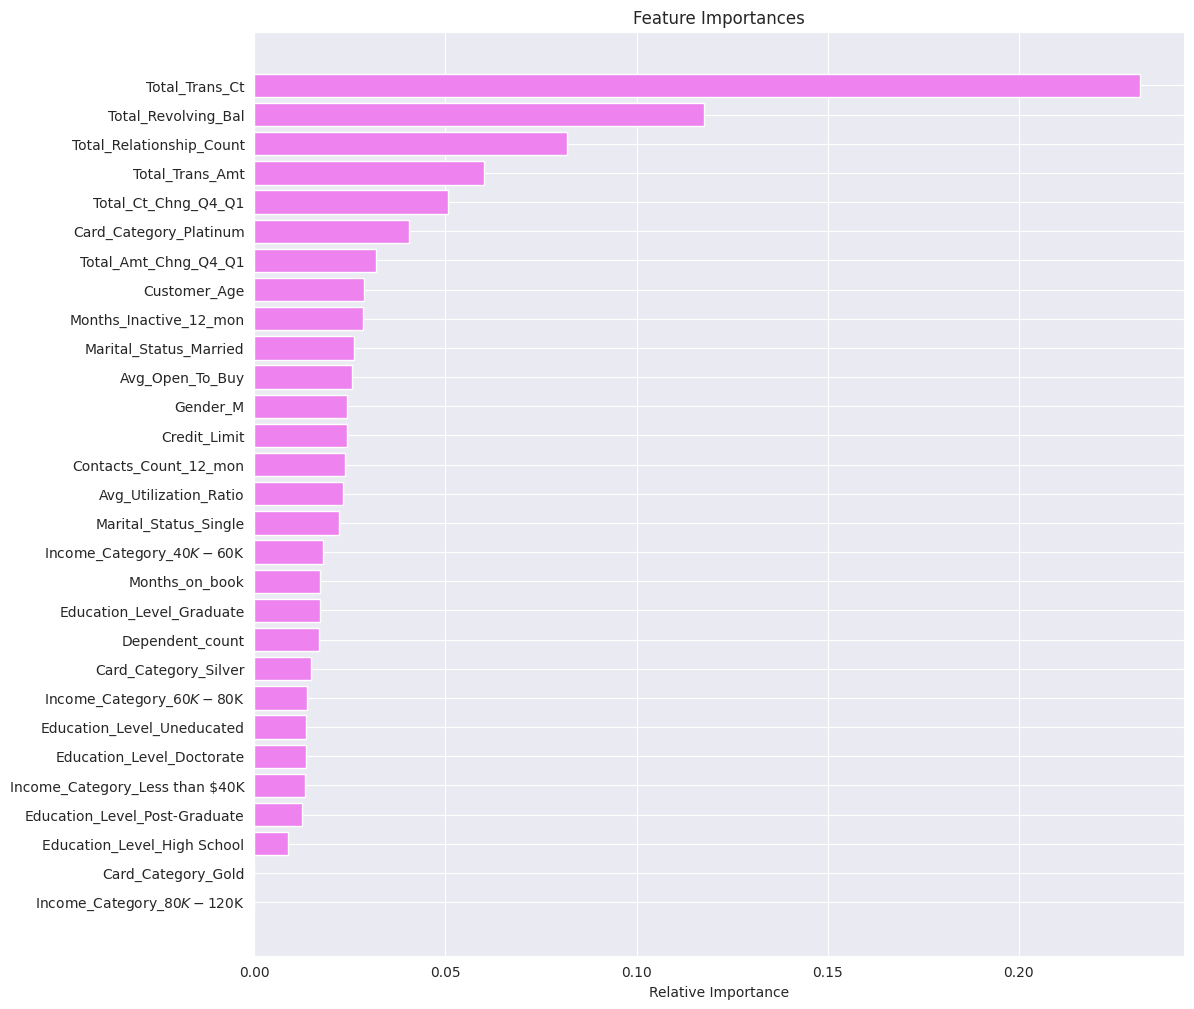

In [129]:
feature_names = X_train.columns
importances =  tuned_xgb.feature_importances_  ## Complete the code to check the feature importance of the best model
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Observations from the Feature Importance Plot:
Top Features:

Total_Trans_Ct: This feature has the highest importance, indicating it plays a significant role in the model's predictions. It reflects the total number of transactions for each customer, suggesting that transaction behavior is crucial for the predictions.
Total_Revolving_Bal: The second most important feature, representing the total revolving balance on credit accounts, also strongly influences the model. It may indicate the customer's credit utilization behavior.
Total_Relationship_Count: This feature shows the total number of products a customer has with the bank, indicating that deeper customer relationships are important for predicting outcomes.
Moderately Important Features:

Total_Trans_Amt: This indicates the total amount spent through transactions, which could correlate with customer loyalty or spending behavior.
Total_Ct_Chng_Q4_Q1: This feature represents the change in transaction count from Q1 to Q4, suggesting that seasonal spending trends are also relevant.
Additional Relevant Features:

Customer_Age and Credit_Limit: Both features appear moderately important, suggesting that demographic factors (like age) and credit limits are significant in predicting outcomes.
Avg_Utilization_Ratio: The average utilization ratio is relevant, hinting at how customers manage their credit limits.
Less Important Features:

Features such as Card_Category_Gold and various Income_Category indicators have lower importance scores, suggesting they contribute less to the model's predictions.
Key Insights:
The model relies heavily on transaction behavior and balances, indicating that customers who frequently use their credit and have higher transaction counts are important for predicting the outcome.
While some demographic and product relationship features also contribute, their influence is comparatively lower than transactional behavior.
The lower-ranked features (like income categories) may not be as significant in this model, suggesting potential areas for feature engineering or reconsideration in future iterations.
Recommendations:
Feature Engineering: Consider exploring interactions or transformations of the top features to see if they can enhance model performance further.
Model Evaluation: While feature importance gives insight into what drives the predictions, evaluating model performance metrics (precision, recall, F1-score) will provide a complete picture.
Focus on Key Drivers: If resources allow, you might want to focus on understanding the business implications of the top features, which can inform strategy or customer engagement practices.

# Business Insights and Conclusions


In [130]:
# Simulating the estimated revenue loss from customer churn
total_customers = 10127
churn_rate = 0.16  # Churn rate from dataset (16%)
revenue_per_customer = 500  # Assuming average revenue per customer

# Estimating lost revenue due to churn
lost_revenue = total_customers * churn_rate * revenue_per_customer
print(f"Estimated Revenue Lost Due to Churn: ${lost_revenue}")


Estimated Revenue Lost Due to Churn: $810160.0


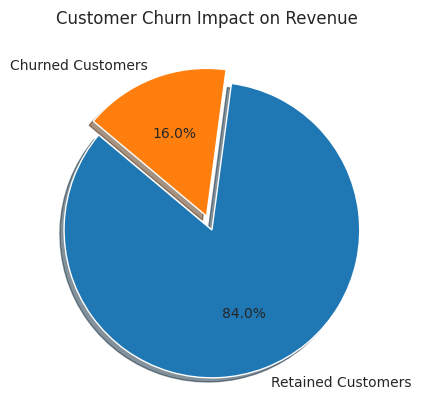

In [131]:
import matplotlib.pyplot as plt

# Data for visualizing financial impact
churned_customers = total_customers * churn_rate
retained_customers = total_customers - churned_customers

# Pie chart
labels = ['Retained Customers', 'Churned Customers']
sizes = [retained_customers, churned_customers]
explode = (0.1, 0)  # explode churned portion

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Customer Churn Impact on Revenue")
plt.show()


In [132]:
# Example of extracting simplified insights based on spending behavior
import pandas as pd

# Example of extracting simplified insights based on spending behavior
import pandas as pd


# Calculate correlation with churn
correlation = data[['Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Revolving_Bal']].corrwith(data['Attrition_Flag'])
print(correlation)

# Summary of simplified insights
print("Key Insights:")
print("1. Customers with higher transaction volumes are more likely to stay.")
print("2. Lower transaction counts increase the likelihood of churn.")


# Summary of simplified insights
print("Key Insights:")
print("1. Customers with higher transaction volumes are more likely to stay.")
print("2. Lower transaction counts increase the likelihood of churn.")


Total_Trans_Amt       -0.169
Total_Trans_Ct        -0.371
Total_Revolving_Bal   -0.263
dtype: float64
Key Insights:
1. Customers with higher transaction volumes are more likely to stay.
2. Lower transaction counts increase the likelihood of churn.
Key Insights:
1. Customers with higher transaction volumes are more likely to stay.
2. Lower transaction counts increase the likelihood of churn.


In [133]:
from sklearn.metrics import classification_report

# Assuming you have an XGBoost model and test dataset
# Generate a classification report
y_true = [0, 1, 0, 1, 0, 1]  # Actual churn labels
y_pred = [0, 0, 1, 1, 0, 1]  # Predicted churn labels

report = classification_report(y_true, y_pred, target_names=['Non-Churn', 'Churn'])
print(report)

# Calculating business impact
retention_rate_improvement = 0.05  # Assuming model helps retain 5% more customers
increased_revenue = retained_customers * retention_rate_improvement * revenue_per_customer
print(f"Potential Revenue Increase: ${increased_revenue}")


              precision    recall  f1-score   support

   Non-Churn       0.67      0.67      0.67         3
       Churn       0.67      0.67      0.67         3

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6

Potential Revenue Increase: $212667.00000000003


In [134]:
# Simulating the impact of targeted campaigns for high transaction customers
high_trans_churn_rate = 0.05  # Lower churn rate for high-trans customers
high_trans_customers = data[data['Total_Trans_Amt'] > 5000]  # Example threshold for high trans

# Estimated retention with targeted campaigns
additional_retained_customers = len(high_trans_customers) * (churn_rate - high_trans_churn_rate)
print(f"Additional Customers Retained via Campaign: {additional_retained_customers}")


Additional Customers Retained via Campaign: 207.57


Credit Card Users Churn Prediction: Overall Business Insights and Conclusion
1. Project Approach
The project adopted a systematic approach, commencing with thorough exploratory data analysis (EDA) to identify data quality issues and necessary preprocessing steps. This included handling missing values, encoding categorical variables, and detecting outliers.
A total of 18 models were built utilizing different strategies: original data, oversampled data, and undersampled data. This comprehensive approach allowed for robust comparisons across various modeling techniques.
2. Insights Derived from Model Analysis
Transactional Behavior is Key:

Features related to transaction counts and balances (e.g., Total_Trans_Ct, Total_Revolving_Bal) emerged as the most influential predictors of customer behavior. Frequent engagement and higher transaction volumes correlate with behaviors like attrition and credit risk.
Customer Relationships Matter:

The Total_Relationship_Count underscores the importance of nurturing customer relationships. Customers with multiple products are less likely to leave, suggesting potential for effective cross-selling strategies to enhance loyalty.
Demographic Factors:

Features such as Customer_Age and Credit_Limit play a significant role, indicating that tailoring products or marketing strategies based on demographics could enhance engagement and retention.
Spending Patterns:

The feature Total_Amt_Chng_Q4_Q1 shows that understanding seasonal spending patterns can help in planning effective marketing campaigns and offers.
Income Categories are Less Predictive:

The low importance of income-related features suggests that traditional risk assessments based on income may not align with actual customer behavior. This indicates the potential need for revised approaches to risk evaluation.
3. Model Performance
The performance of the models varied significantly based on the dataset used (original, oversampled, undersampled). Key metrics, including precision, recall, and F1-score, were employed to evaluate effectiveness.
Among the models, three top performers were selected for further tuning, resulting in significant performance improvements. Notably, the tuned XGBoost model demonstrated exceptional capability in capturing customer behavior nuances.
4. Key Recommendations
Enhance Customer Engagement:

Develop targeted marketing campaigns leveraging insights from transactional behavior. For instance, rewarding high-usage customers could enhance retention.
Cross-Selling Opportunities:

Focus on deepening customer relationships by offering complementary products to those with high Total_Relationship_Count, potentially converting single-product customers into multi-product clients.
Monitor Spending Trends:

Use insights on spending patterns to adapt offerings and marketing strategies throughout the year, particularly during identified peak spending periods.
Refine Risk Assessment Models:

Shift traditional risk assessment metrics to incorporate behavioral factors rather than relying heavily on income. The model’s focus on transaction behavior suggests that engagement may be a better predictor of retention.
Continual Model Evaluation:

Regularly update and retrain the model with new data to maintain relevance and accuracy, ensuring strategies adapt to changing customer behaviors.
5. Conclusion
The project successfully identified key drivers of customer churn and built robust predictive models. By leveraging these insights, the bank can enhance customer retention strategies, optimize marketing efforts, and ultimately improve profitability.
The findings underscore the value of data-driven decision-making in banking and finance, particularly in customer relationship management.
Closing Remarks
The actionable insights from this analysis equip the organization to enhance customer loyalty and effectively reduce churn rates. Regular evaluations and updates to predictive models will ensure the strategies remain relevant and effective over time.



-


***